# HAT Clustering Analysis — Emotional vs Neutral (Per-Prompt Isolated)

Each data point is one permutation run — a full inference over a concatenated sequence of stories,
isolated via server reset + cache drop before each trial.

**Data layout per data point** (`runs/<label>/p<NNNN>/`):
```
perf_stat.csv        — 1ms buckets, 24 perf events (HAT Layer 1 tracepoints + Layer 2 PMU/power)
hat_interrupts.csv   — 100ms: /proc/interrupts, /proc/softirqs, CPU freq per core
proc_sample.csv      — 100ms: system + per-process CPU jiffies, RSS
collector_meta.json  — t0_ns, duration, perf_events list
trial_meta.json      — prompt_index, label, ok, t_request_start_ns, t_request_end_ns, elapsed_ms
```

**Experimental design:**
- 120 emotional permutations (5! orderings of 5 ptsd
 stories)
- 120 neutral permutations (5! orderings of 5 WikiHow articles)
- Neutral prompts are shorter on average → `elapsed_ms` used as a confounder proxy for prompt length
- Each trial is fully isolated: server reset + `drop_caches` + 2s stabilisation baseline

**Analysis approach:**
1. Extract 10 indicator metrics per HAT indicator (event-specific or PCI-specific, as appropriate)
2. Build a feature matrix: 240 rows × N metrics
3. Per-metric univariate screening (Mann-Whitney U + effect size)
4. Per-metric k=2 clustering → silhouette score → rank metrics by separability
5. Multi-metric GMM clustering on top-K features
6. Confounder check: elapsed_ms (prompt duration proxy for length difference)
7. PCoA / UMAP visualisation


In [1]:
import json, re, warnings
from pathlib import Path
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy.stats as sp_stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print('Imports OK')

Imports OK


## 1 — Configuration

In [2]:
BASE_DIR = Path.home() / 'Desktop' / 'mccviahat'

print(f'BASE_DIR = {BASE_DIR}')
assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'


BASE_DIR = /Users/rsalvi/Desktop/mccviahat


## 2 — Load features


In [3]:
_node = 'clemsonc6420'
_data_dir = BASE_DIR / 'data' / _node

_csvR = _data_dir / 'CLtrainR.csv'
_csvE = _data_dir / 'CLtrainE.csv'

for p in (_csvR, _csvE):
    assert p.exists(), (
        f'{p.name} not found at {p}\n'
        'Run: python scripts/run/extract_features.py <split>'
    )

df_all = pd.concat(
    [pd.read_csv(_csvR), pd.read_csv(_csvE)],
    ignore_index=True,
)

print(f'Loaded:')
print(f'  {_csvR}')
print(f'  {_csvE}')
print(f'  {len(df_all)} trials total  |  '
      f'neutral: {(df_all.condition=="neutral").sum()}  |  '
      f'emotional: {(df_all.condition=="emotional").sum()}')
print(f'  Feature columns: {len([c for c in df_all.columns if "__" in c])}')


Loaded:
  /Users/rsalvi/Desktop/mccviahat/data/clemsonc6420/CLtrainR.csv
  /Users/rsalvi/Desktop/mccviahat/data/clemsonc6420/CLtrainE.csv
  40 trials total  |  neutral: 20  |  emotional: 20
  Feature columns: 550


## 3 — Confounder check: elapsed_ms

Neutral prompts are shorter. If elapsed_ms differs significantly between conditions,
any metric that scales with prompt duration is a confounder, not a true signal.
We check this explicitly and will flag length-sensitive metrics.


In [4]:
from scipy import stats as sp_stats

# elapsed_ms per condition
dur_n = df_all.loc[df_all.condition == 'neutral',   'elapsed_ms'].dropna().values
dur_e = df_all.loc[df_all.condition == 'emotional', 'elapsed_ms'].dropna().values

stat, p_len = sp_stats.mannwhitneyu(dur_n, dur_e, alternative='two-sided')

print(f'Neutral   elapsed_ms:  mean={dur_n.mean():.0f} ms, median={np.median(dur_n):.0f} ms, n={len(dur_n)}')
print(f'Emotional elapsed_ms:  mean={dur_e.mean():.0f} ms, median={np.median(dur_e):.0f} ms, n={len(dur_e)}')
print(f'Mann-Whitney U={stat:.0f},  p={p_len:.4g}')
print()
if p_len < 0.05:
    print('⚠  elapsed_ms differs significantly between conditions (p < 0.05).')
    print('   Metrics that scale with duration may be confounded by prompt length.')
else:
    print('✓  No significant difference in elapsed_ms between conditions.')

# Shared bin edges for the histogram below
all_dur = np.concatenate([dur_n, dur_e])
bins = np.linspace(all_dur.min(), all_dur.max(), 30)


Neutral   elapsed_ms:  mean=14917 ms, median=14300 ms, n=20
Emotional elapsed_ms:  mean=14943 ms, median=14338 ms, n=20
Mann-Whitney U=173,  p=0.4735

✓  No significant difference in elapsed_ms between conditions.


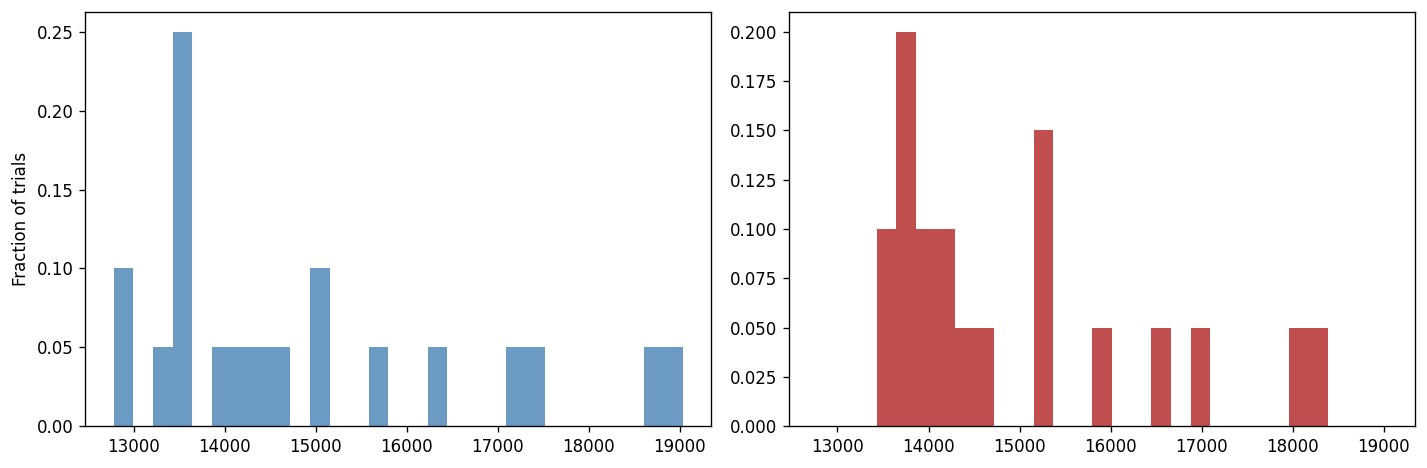


Length confound flag: False
Note: mean_rate is normalised by dur_s, so it is NOT confounded by length.
Metrics like burst_rate (per-second) are also duration-normalised.
Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.


In [5]:
weights_n = np.ones(len(dur_n)) / len(dur_n)
weights_e = np.ones(len(dur_e)) / len(dur_e)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].hist(dur_n, bins=bins, weights=weights_n, color='steelblue', alpha=0.8)
axes[1].hist(dur_e, bins=bins, weights=weights_e, color='firebrick', alpha=0.8)

axes[0].set_ylabel('Fraction of trials')
plt.tight_layout()
plt.show()

LENGTH_CONFOUNDED = p_len < 0.05
print(f'\nLength confound flag: {LENGTH_CONFOUNDED}')
print('Note: mean_rate is normalised by dur_s, so it is NOT confounded by length.')
print('Metrics like burst_rate (per-second) are also duration-normalised.')
print('Metrics like variance, p90_p10, lz_complexity may scale with duration → flag if sig.')

In [6]:
# --- Feature selection: include/exclude length-confounded features ---
from typing import List

# List of metrics that may be length-confounded
LENGTH_CONFOUNDED_METRICS = {
    'variance', 'p90_p10', 'lz_complexity', 'perm_entropy', 'spectral_entropy'
}
'''LENGTH_CONFOUNDED_METRICS = {
     'p90_p10', 'perm_entropy'
}'''
feature_cols = [c for c in df_all.columns if '__' in c]

def metric_of(col: str) -> str:
    # evt__metric
    return col.split('__', 1)[1]

length_confounded_cols   = [c for c in feature_cols if metric_of(c) in LENGTH_CONFOUNDED_METRICS]
length_unconfounded_cols = [c for c in feature_cols if metric_of(c) not in LENGTH_CONFOUNDED_METRICS]

print(f"Length-confounded features: {len(length_confounded_cols)}")
print(f"Length-unconfounded features: {len(length_unconfounded_cols)}")

# User selection: set to True to include, False to exclude length-confounded features
INCLUDE_LENGTH_CONFOUNDED = True  # <-- change this to True to include them

if INCLUDE_LENGTH_CONFOUNDED:
    selected_cols = length_unconfounded_cols + length_confounded_cols
    print("Including ALL features (length-confounded and unconfounded).")
else:
    selected_cols = length_unconfounded_cols
    print("Excluding length-confounded features.")

# Subset the feature matrix for downstream analysis
X = df_all[selected_cols].copy()
print(f"Final feature matrix shape: {X.shape}")

Length-confounded features: 275
Length-unconfounded features: 275
Including ALL features (length-confounded and unconfounded).
Final feature matrix shape: (40, 550)


In [7]:
"""# --- Regress out elapsed_ms from all features ---
import re
from sklearn.linear_model import LinearRegression
import numpy as np
# Regress out token_count and elapsed_ms from all feature columns
feature_cols = [c for c in df_all.columns if '__' in c]
for col in feature_cols:
    y_feat = df_all[col].values
    X_reg = df_all[['elapsed_ms']].values
    mask = np.isfinite(y_feat) & np.all(np.isfinite(X_reg), axis=1)
    if mask.sum() < 10:
        continue
    reg = LinearRegression()
    reg.fit(X_reg[mask], y_feat[mask])
    y_pred = reg.predict(X_reg)
    df_all[col] = y_feat - y_pred  # Replace with residuals

print("Regressed out elapsed_ms from all features.")"""

'# --- Regress out elapsed_ms from all features ---\nimport re\nfrom sklearn.linear_model import LinearRegression\nimport numpy as np\n# Regress out token_count and elapsed_ms from all feature columns\nfeature_cols = [c for c in df_all.columns if \'__\' in c]\nfor col in feature_cols:\n    y_feat = df_all[col].values\n    X_reg = df_all[[\'elapsed_ms\']].values\n    mask = np.isfinite(y_feat) & np.all(np.isfinite(X_reg), axis=1)\n    if mask.sum() < 10:\n        continue\n    reg = LinearRegression()\n    reg.fit(X_reg[mask], y_feat[mask])\n    y_pred = reg.predict(X_reg)\n    df_all[col] = y_feat - y_pred  # Replace with residuals\n\nprint("Regressed out elapsed_ms from all features.")'

## 6 — Build feature matrix and clean

In [8]:
# --- Build feature matrix and clean ---
# Use selected_cols from previous cell (already filtered for confounding)

META_COLS = {'condition', 'prompt_index', 'elapsed_ms', 'dur_s'}
feat_cols = [c for c in X.columns if c not in META_COLS]

X_raw = X[feat_cols].copy()
y = (df_all['condition'] == 'emotional').astype(int).values  # 0=neutral, 1=emotional

# Drop zero-variance columns and fill NaN
X_raw = X_raw.loc[:, X_raw.std() > 0]
X_raw = X_raw.fillna(X_raw.median())

feat_cols = list(X_raw.columns)
print(f'Feature matrix: {X_raw.shape[0]} samples × {X_raw.shape[1]} features')

# Standardise
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X_raw), columns=feat_cols)
print('Standardised.')

Feature matrix: 40 samples × 342 features
Standardised.


In [9]:
# --- Diagnostics: Check feature selection logic ---
print(f"INCLUDE_LENGTH_CONFOUNDED = {INCLUDE_LENGTH_CONFOUNDED}")
print(f"Length-confounded features matched: {len(length_confounded_cols)}")
print(f"Length-unconfounded features matched: {len(length_unconfounded_cols)}")
print(f"Selected columns: {len(selected_cols)}")
print(f"First 10 selected columns: {selected_cols[:10]}")
print(f"Final feature matrix shape after cleaning: {X.shape}")

INCLUDE_LENGTH_CONFOUNDED = True
Length-confounded features matched: 275
Length-unconfounded features matched: 275
Selected columns: 550
First 10 selected columns: ['irq:irq_handler_entry__mean_rate', 'irq:irq_handler_entry__slope', 'irq:irq_handler_entry__iat_cv', 'irq:irq_handler_entry__burst_rate', 'irq:irq_handler_entry__burst_clustering', 'irq:irq_handler_exit__mean_rate', 'irq:irq_handler_exit__slope', 'irq:irq_handler_exit__iat_cv', 'irq:irq_handler_exit__burst_rate', 'irq:irq_handler_exit__burst_clustering']
Final feature matrix shape after cleaning: (40, 342)


## 7 — Univariate screening: Mann-Whitney U per metric

Non-parametric test for each feature. We report effect size (rank-biserial r) and direction.

In [10]:
results = []
n_vals = X_raw[y == 0]
e_vals = X_raw[y == 1]

for col in feat_cols:
    nv = n_vals[col].dropna().values
    ev = e_vals[col].dropna().values
    if len(nv) < 5 or len(ev) < 5:
        continue
    if nv.std() == 0 and ev.std() == 0:
        continue
    stat, p = sp_stats.mannwhitneyu(nv, ev, alternative='two-sided')
    r = 1 - (2 * stat) / (len(nv) * len(ev))  # rank-biserial r
    results.append({
        'feature':   col,
        'U':         stat,
        'p':         p,
        'effect_r':  r,
        'n_mean':    nv.mean(),
        'e_mean':    ev.mean(),
        'direction': '↑E' if ev.mean() > nv.mean() else '↓E',
    })

mwu_df = pd.DataFrame(results).sort_values('p').reset_index(drop=True)

# Bonferroni-corrected threshold
alpha_raw = 0.05
alpha_bonf = alpha_raw / len(mwu_df)
sig_strict = mwu_df[mwu_df.p < alpha_bonf]
sig_nominal = mwu_df[mwu_df.p < alpha_raw]

print(f'Features tested: {len(mwu_df)}')
print(f'Significant at p<{alpha_raw} (nominal):    {len(sig_nominal)}')
print(f'Significant at p<{alpha_bonf:.2e} (Bonferroni): {len(sig_strict)}')
print()
print('=== Top 30 features by p-value ===')
print(mwu_df.head(30)[['feature', 'U', 'p', 'effect_r', 'direction']].to_string(
    index=False, float_format='{:.4f}'.format))

Features tested: 342
Significant at p<0.05 (nominal):    30
Significant at p<1.46e-04 (Bonferroni): 11

=== Top 30 features by p-value ===
                                feature        U      p  effect_r direction
                       hat_BLOCK__slope   6.0000 0.0000    0.9700        ↑E
            hat_BLOCK__spectral_entropy 391.0000 0.0000   -0.9550        ↓E
                    hat_BLOCK__variance 383.0000 0.0000   -0.9150        ↓E
           irq:irq_handler_entry__slope  43.0000 0.0000    0.7850        ↑E
            irq:irq_handler_exit__slope  43.0000 0.0000    0.7850        ↑E
        irq:irq_handler_entry__variance 351.0000 0.0000   -0.7550        ↓E
         irq:irq_handler_exit__variance 351.0000 0.0000   -0.7550        ↓E
                   hat_BLOCK__mean_rate 347.0000 0.0001   -0.7350        ↓E
 irq:irq_handler_exit__spectral_entropy 347.0000 0.0001   -0.7350        ↓E
irq:irq_handler_entry__spectral_entropy 347.0000 0.0001   -0.7350        ↓E
                  hat_BLO

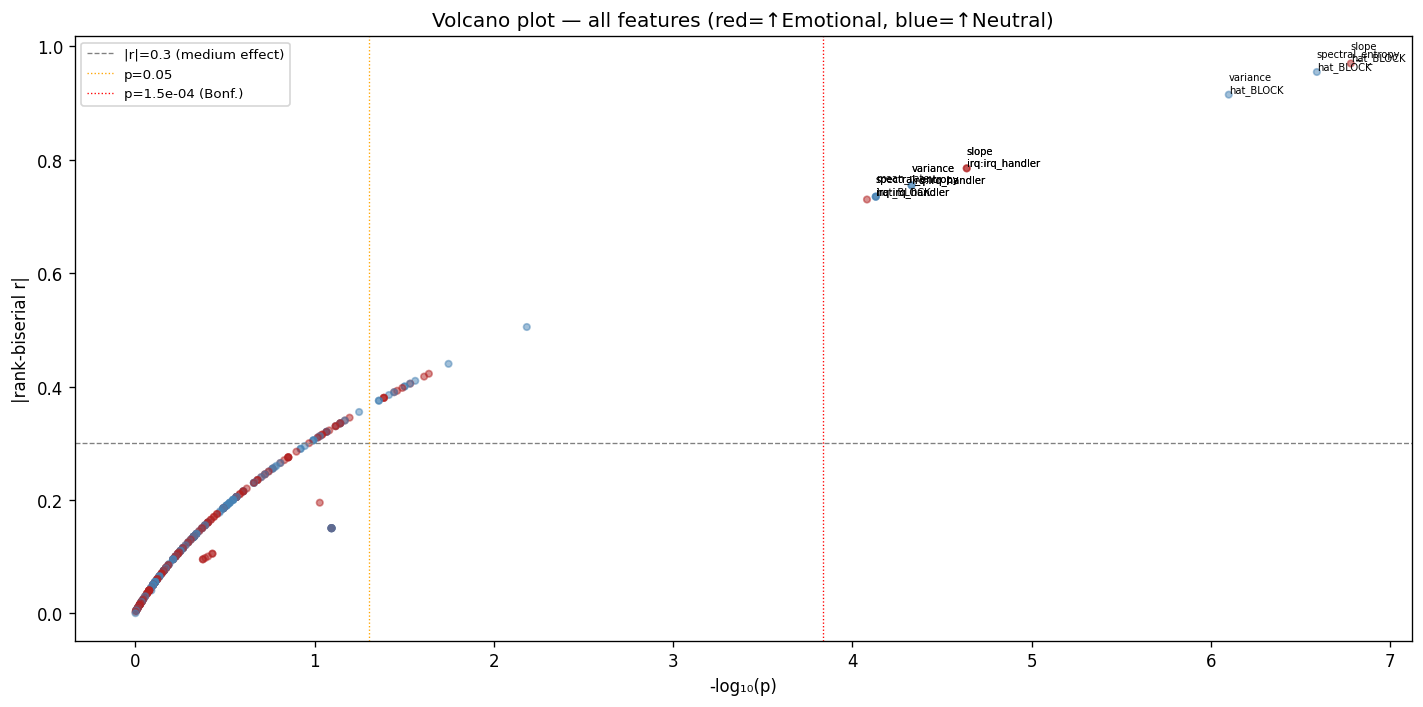

In [11]:
# Volcano plot: effect size vs -log10(p)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['firebrick' if r > 0 else 'steelblue' for r in mwu_df.effect_r]
ax.scatter(-np.log10(mwu_df.p + 1e-15), mwu_df.effect_r.abs(),
           c=colors, alpha=0.5, s=15)
ax.axhline(0.3, ls='--', color='gray', lw=0.8, label='|r|=0.3 (medium effect)')
ax.axvline(-np.log10(alpha_raw), ls=':', color='orange', lw=0.8, label=f'p={alpha_raw}')
ax.axvline(-np.log10(alpha_bonf), ls=':', color='red', lw=0.8, label=f'p={alpha_bonf:.1e} (Bonf.)')
# Label top 10
for _, row in mwu_df.head(10).iterrows():
    ax.annotate(row.feature.split('__')[-1] + '\n' + row.feature.split('__')[0][:15],
                xy=(-np.log10(row.p + 1e-15), abs(row.effect_r)),
                fontsize=6, ha='left', va='bottom')
ax.set_xlabel('-log₁₀(p)')
ax.set_ylabel('|rank-biserial r|')
ax.set_title('Volcano plot — all features (red=↑Emotional, blue=↑Neutral)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8 — Per-metric k=2 clustering → silhouette ranking

For each feature independently, fit k-means with k=2 and score how well the
resulting clusters align with the ground-truth labels.

Two scores per feature:
- **Silhouette**: geometric cluster quality (−1 to 1, higher = more separated)
- **ARI** (Adjusted Rand Index): overlap with true labels (0=random, 1=perfect)

In [12]:
cluster_results = []

for col in feat_cols:
    x1d = X[[col]].values
    if np.isnan(x1d).any():
        continue
    km = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels_pred = km.fit_predict(x1d)
    ari = adjusted_rand_score(y, labels_pred)
    # Cluster purity: fraction of majority label in each cluster
    mask0 = labels_pred == 0
    mask1 = labels_pred == 1
    purity = max(
        (y[mask0] == 0).mean() if mask0.sum() > 0 else 0,
        (y[mask0] == 1).mean() if mask0.sum() > 0 else 0,
    ) * 0.5 + max(
        (y[mask1] == 0).mean() if mask1.sum() > 0 else 0,
        (y[mask1] == 1).mean() if mask1.sum() > 0 else 0,
    ) * 0.5
    acc = max((labels_pred == y).mean(), (1 - labels_pred == y).mean())
    cluster_results.append({
        'feature': col,
        'ari':     ari,
        'acc':     acc,
        'purity':  purity,
    })

clust_df = pd.DataFrame(cluster_results).sort_values('ari', ascending=False).reset_index(drop=True)
print('=== Top 30 features by ARI (k-means k=2 vs ground truth) ===')
print(clust_df.head(30).to_string(index=False, float_format='{:.4f}'.format))


=== Top 30 features by ARI (k-means k=2 vs ground truth) ===
                                  feature    ari    acc  purity
              hat_BLOCK__spectral_entropy 0.8051 0.9500  0.9545
                         hat_BLOCK__slope 0.7152 0.9250  0.9261
  irq:irq_handler_entry__spectral_entropy 0.5513 0.8750  0.8836
   irq:irq_handler_exit__spectral_entropy 0.5513 0.8750  0.8836
                      hat_BLOCK__variance 0.5510 0.8750  0.8759
          irq:irq_handler_entry__variance 0.3433 0.8000  0.8030
           irq:irq_handler_exit__variance 0.3433 0.8000  0.8030
                     hat_BLOCK__mean_rate 0.2305 0.7500  0.7525
                  tlb:tlb_flush__variance 0.2305 0.7500  0.7525
                    hat_BLOCK__burst_rate 0.1065 0.6750  0.7509
         irq:irq_handler_entry__mean_rate 0.1023 0.6750  0.6994
          irq:irq_handler_exit__mean_rate 0.1023 0.6750  0.6994
                      hat_TLB__burst_rate 0.1023 0.6750  0.6994
                        hat_TLB__variance 0

In [13]:
# Combine MWU p-value and per-feature k-means ARI into one ranking table
ranking = mwu_df[['feature', 'p', 'effect_r', 'direction']].merge(
    clust_df[['feature', 'ari', 'acc', 'purity']], on='feature', how='inner')

# Composite score: equal weight on p-rank and ARI-rank
ranking['p_rank']   = ranking['p'].rank()
ranking['ari_rank'] = (-ranking['ari']).rank()   # lower rank = higher ARI
ranking['composite_rank'] = ranking[['p_rank', 'ari_rank']].mean(axis=1)
ranking = ranking.sort_values('composite_rank').reset_index(drop=True)

print('=== Combined ranking (MWU p + k-means ARI) — top 30 ===')
print(ranking.head(30)[['feature','p','effect_r','direction','ari','acc','purity']]
      .to_string(index=False, float_format='{:.4f}'.format))


=== Combined ranking (MWU p + k-means ARI) — top 30 ===
                                  feature      p  effect_r direction    ari    acc  purity
                         hat_BLOCK__slope 0.0000    0.9700        ↑E 0.7152 0.9250  0.9261
              hat_BLOCK__spectral_entropy 0.0000   -0.9550        ↓E 0.8051 0.9500  0.9545
                      hat_BLOCK__variance 0.0000   -0.9150        ↓E 0.5510 0.8750  0.8759
   irq:irq_handler_exit__spectral_entropy 0.0001   -0.7350        ↓E 0.5513 0.8750  0.8836
  irq:irq_handler_entry__spectral_entropy 0.0001   -0.7350        ↓E 0.5513 0.8750  0.8836
          irq:irq_handler_entry__variance 0.0000   -0.7550        ↓E 0.3433 0.8000  0.8030
           irq:irq_handler_exit__variance 0.0000   -0.7550        ↓E 0.3433 0.8000  0.8030
                     hat_BLOCK__mean_rate 0.0001   -0.7350        ↓E 0.2305 0.7500  0.7525
                    hat_BLOCK__burst_rate 0.0001    0.7300        ↑E 0.1065 0.6750  0.7509
                        hat_TLB__v

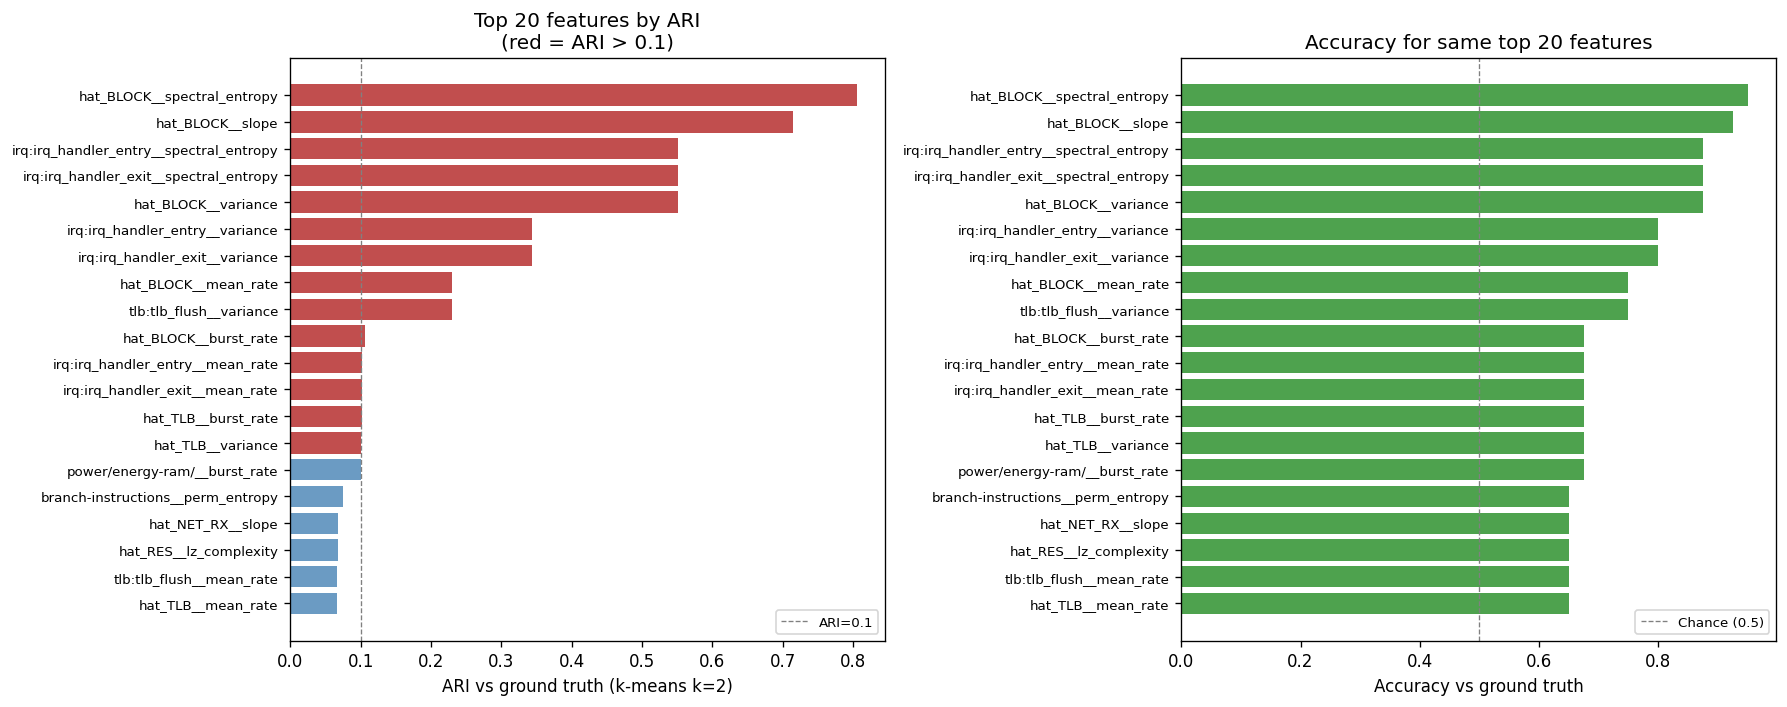

In [14]:
# Bar chart: top 20 features by ARI vs ground truth
top20 = clust_df.head(20)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: ARI
ax = axes[0]
colors = ['firebrick' if row.ari > 0.1 else 'steelblue' for _, row in top20.iterrows()]
ax.barh(range(len(top20)), top20.ari, color=colors, alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.feature, fontsize=8)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.5)
ax.axvline(0.1, color='gray', lw=0.8, ls='--', label='ARI=0.1')
ax.set_xlabel('ARI vs ground truth (k-means k=2)')
ax.set_title('Top 20 features by ARI\n(red = ARI > 0.1)')
ax.legend(fontsize=8)

# Right: accuracy
ax = axes[1]
colors2 = ['forestgreen' if row.acc > 0.6 else 'salmon' for _, row in top20.iterrows()]
ax.barh(range(len(top20)), top20.acc, color=colors2, alpha=0.8)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.feature, fontsize=8)
ax.invert_yaxis()
ax.axvline(0.5, color='gray', lw=0.8, ls='--', label='Chance (0.5)')
ax.set_xlabel('Accuracy vs ground truth')
ax.set_title('Accuracy for same top 20 features')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 10 — GMM clustering on top-K features

Select the top K features by composite rank, fit a 2-component GMM, and evaluate
cluster assignment against ground-truth labels.

In [15]:
TOP_K = 7  # adjust after inspecting ranking

top_features = ranking.head(TOP_K)['feature'].tolist()
X_top = X[top_features].values

# GMM with k=2
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=10)
gmm.fit(X_top)
gmm_labels = gmm.predict(X_top)
gmm_probs  = gmm.predict_proba(X_top)

ari_gmm = adjusted_rand_score(y, gmm_labels)

# Align GMM label 0/1 to neutral/emotional
# (GMM labels are arbitrary — check which assignment gives better accuracy)
acc_direct  = (gmm_labels == y).mean()
acc_flipped = (1 - gmm_labels == y).mean()
if acc_flipped > acc_direct:
    gmm_labels = 1 - gmm_labels
    gmm_probs  = gmm_probs[:, ::-1]
accuracy = (gmm_labels == y).mean()

print(f'GMM (k=2) on top {TOP_K} features:')
print(f'  ARI:      {ari_gmm:.4f}')
print(f'  Accuracy vs ground truth: {accuracy:.1%}')
print(f'  Neutral correctly assigned:   {(gmm_labels[y==0] == 0).mean():.1%}')
print(f'  Emotional correctly assigned: {(gmm_labels[y==1] == 1).mean():.1%}')
print(f'\nFeatures: {top_features}')


GMM (k=2) on top 7 features:
  ARI:      0.6309
  Accuracy vs ground truth: 90.0%
  Neutral correctly assigned:   100.0%
  Emotional correctly assigned: 80.0%

Features: ['hat_BLOCK__slope', 'hat_BLOCK__spectral_entropy', 'hat_BLOCK__variance', 'irq:irq_handler_exit__spectral_entropy', 'irq:irq_handler_entry__spectral_entropy', 'irq:irq_handler_entry__variance', 'irq:irq_handler_exit__variance']


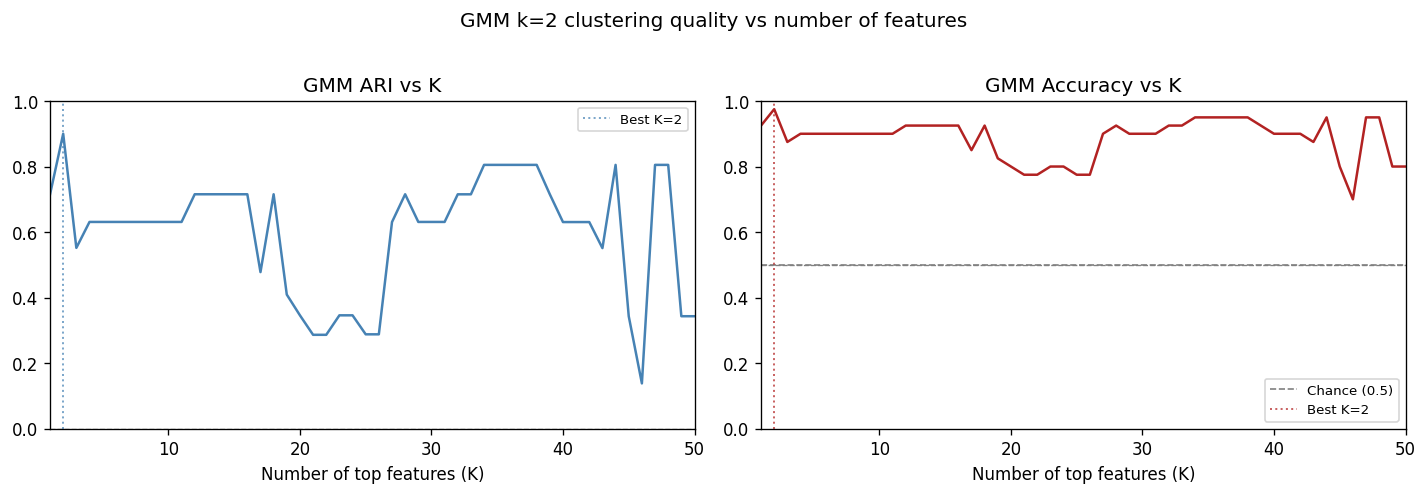

Best ARI = 0.8999 at K=2
Best Acc = 0.9750 at K=2


In [16]:
# Sweep K from 1 to 50: how does GMM clustering quality scale with number of features?
K_vals = list(range(1, min(51, len(feat_cols) + 1)))
ari_vals, acc_vals = [], []

for k in K_vals:
    feats = ranking.head(k)['feature'].tolist()
    Xk = X[feats].values
    try:
        gmm_k = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=5)
        lbl = gmm_k.fit_predict(Xk)
        ari_k = adjusted_rand_score(y, lbl)
        acc_k = max((lbl == y).mean(), (1 - lbl == y).mean())
        ari_vals.append(ari_k)
        acc_vals.append(acc_k)
    except Exception:
        ari_vals.append(np.nan)
        acc_vals.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, vals, title, color, hline in [
    (axes[0], ari_vals, 'GMM ARI vs K',       'steelblue',  0.0),
    (axes[1], acc_vals, 'GMM Accuracy vs K',  'firebrick',  0.5),
]:
    ax.plot(K_vals, vals, color=color, lw=1.5)
    ax.axhline(hline, color='gray', lw=0.8, ls='--')
    ax.set_ylim(0, 1)
    ax.set_xlim(min(K_vals), max(K_vals))
    ax.set_xlabel('Number of top features (K)')
    ax.set_title(title)

axes[1].axhline(0.5, color='gray', lw=1.0, ls='--', label='Chance (0.5)')
axes[1].legend(fontsize=8)

best_ari_k = K_vals[int(np.nanargmax(ari_vals))]
best_acc_k = K_vals[int(np.nanargmax(acc_vals))]
axes[0].axvline(best_ari_k, color='steelblue', lw=1.2, ls=':', alpha=0.7, label=f'Best K={best_ari_k}')
axes[1].axvline(best_acc_k, color='firebrick', lw=1.2, ls=':', alpha=0.7, label=f'Best K={best_acc_k}')
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)

plt.suptitle('GMM k=2 clustering quality vs number of features', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Best ARI = {max(v for v in ari_vals if not np.isnan(v)):.4f} at K={best_ari_k}')
print(f'Best Acc = {max(v for v in acc_vals if not np.isnan(v)):.4f} at K={best_acc_k}')


In [17]:
k_df = pd.DataFrame({
    'K':        K_vals,
    'ARI':      ari_vals,
    'Accuracy': acc_vals,
})
k_df_clean = k_df.dropna()

print('=== K-sweep summary statistics ===\n')
for metric in ['ARI', 'Accuracy']:
    vals = k_df_clean[metric].values
    ks   = k_df_clean['K'].values
    max_idx = np.argmax(vals)
    min_idx = np.argmin(vals)
    print(f'{metric}:')
    print(f'  Max  = {vals[max_idx]:.4f} at K = {ks[max_idx]}')
    print(f'  Min  = {vals[min_idx]:.4f} at K = {ks[min_idx]}')
    print(f'  Mean = {np.mean(vals):.4f}  Std = {np.std(vals):.4f}')
    print()

best_ari_k = int(k_df_clean.loc[k_df_clean['ARI'].idxmax(), 'K'])
best_acc_k = int(k_df_clean.loc[k_df_clean['Accuracy'].idxmax(), 'K'])
print(f'Best ARI at K = {best_ari_k}')
print(f'Best Accuracy at K = {best_acc_k}')


=== K-sweep summary statistics ===

ARI:
  Max  = 0.8999 at K = 2
  Min  = 0.1381 at K = 46
  Mean = 0.6003  Std = 0.1811

Accuracy:
  Max  = 0.9750 at K = 2
  Min  = 0.7000 at K = 46
  Mean = 0.8855  Std = 0.0623

Best ARI at K = 2
Best Accuracy at K = 2


## 11 — PCA visualisation of cluster structure

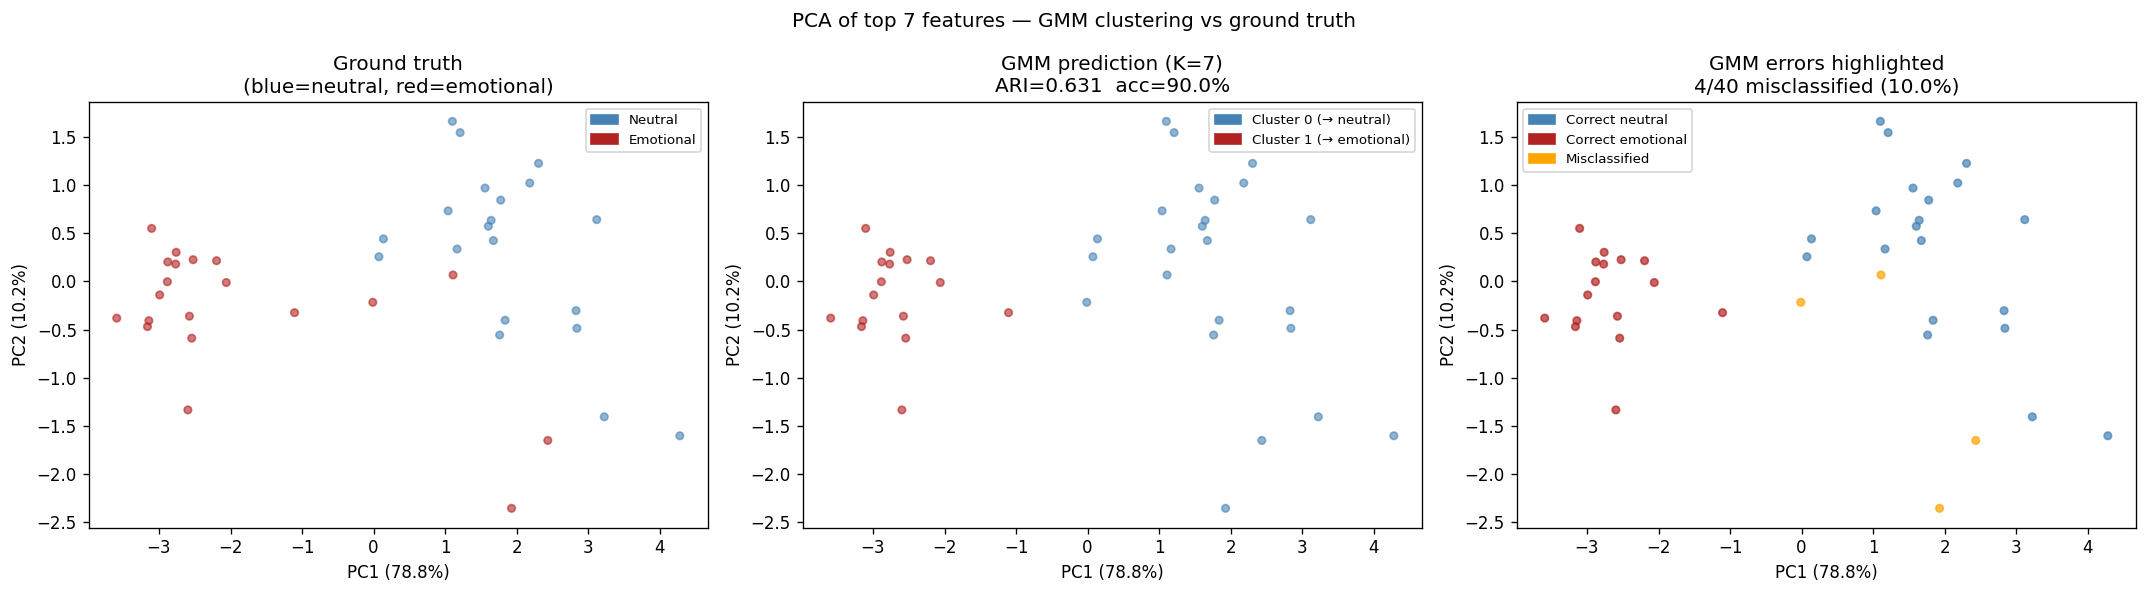

PCA explained variance: PC1=78.8%, PC2=10.2%


In [18]:
from matplotlib.patches import Patch

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X[top_features].values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: ground truth
ax = axes[0]
gt_colors = ['steelblue' if yi == 0 else 'firebrick' for yi in y]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=gt_colors, alpha=0.6, s=20)
ax.set_title(f'Ground truth\n(blue=neutral, red=emotional)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(handles=[Patch(color='steelblue', label='Neutral'),
                   Patch(color='firebrick', label='Emotional')], fontsize=8)

# Panel 2: GMM prediction
ax = axes[1]
colors_pred = ['steelblue' if l == 0 else 'firebrick' for l in gmm_labels]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_pred, alpha=0.6, s=20)
ax.set_title(f'GMM prediction (K={TOP_K})\nARI={ari_gmm:.3f}  acc={accuracy:.1%}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(handles=[Patch(color='steelblue', label='Cluster 0 (→ neutral)'),
                   Patch(color='firebrick', label='Cluster 1 (→ emotional)')], fontsize=8)

# Panel 3: errors — where did GMM go wrong?
ax = axes[2]
correct = gmm_labels == y
point_colors = []
for gi, yi, ci in zip(gmm_labels, y, correct):
    if ci:
        point_colors.append('steelblue' if yi == 0 else 'firebrick')
    else:
        point_colors.append('orange')  # misclassified
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=point_colors, alpha=0.7, s=20)
n_errors = (~correct).sum()
ax.set_title(f'GMM errors highlighted\n{n_errors}/{len(y)} misclassified ({n_errors/len(y):.1%})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(handles=[Patch(color='steelblue', label='Correct neutral'),
                   Patch(color='firebrick', label='Correct emotional'),
                   Patch(color='orange',    label='Misclassified')], fontsize=8)

plt.suptitle(f'PCA of top {TOP_K} features — GMM clustering vs ground truth', fontsize=12)
plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')


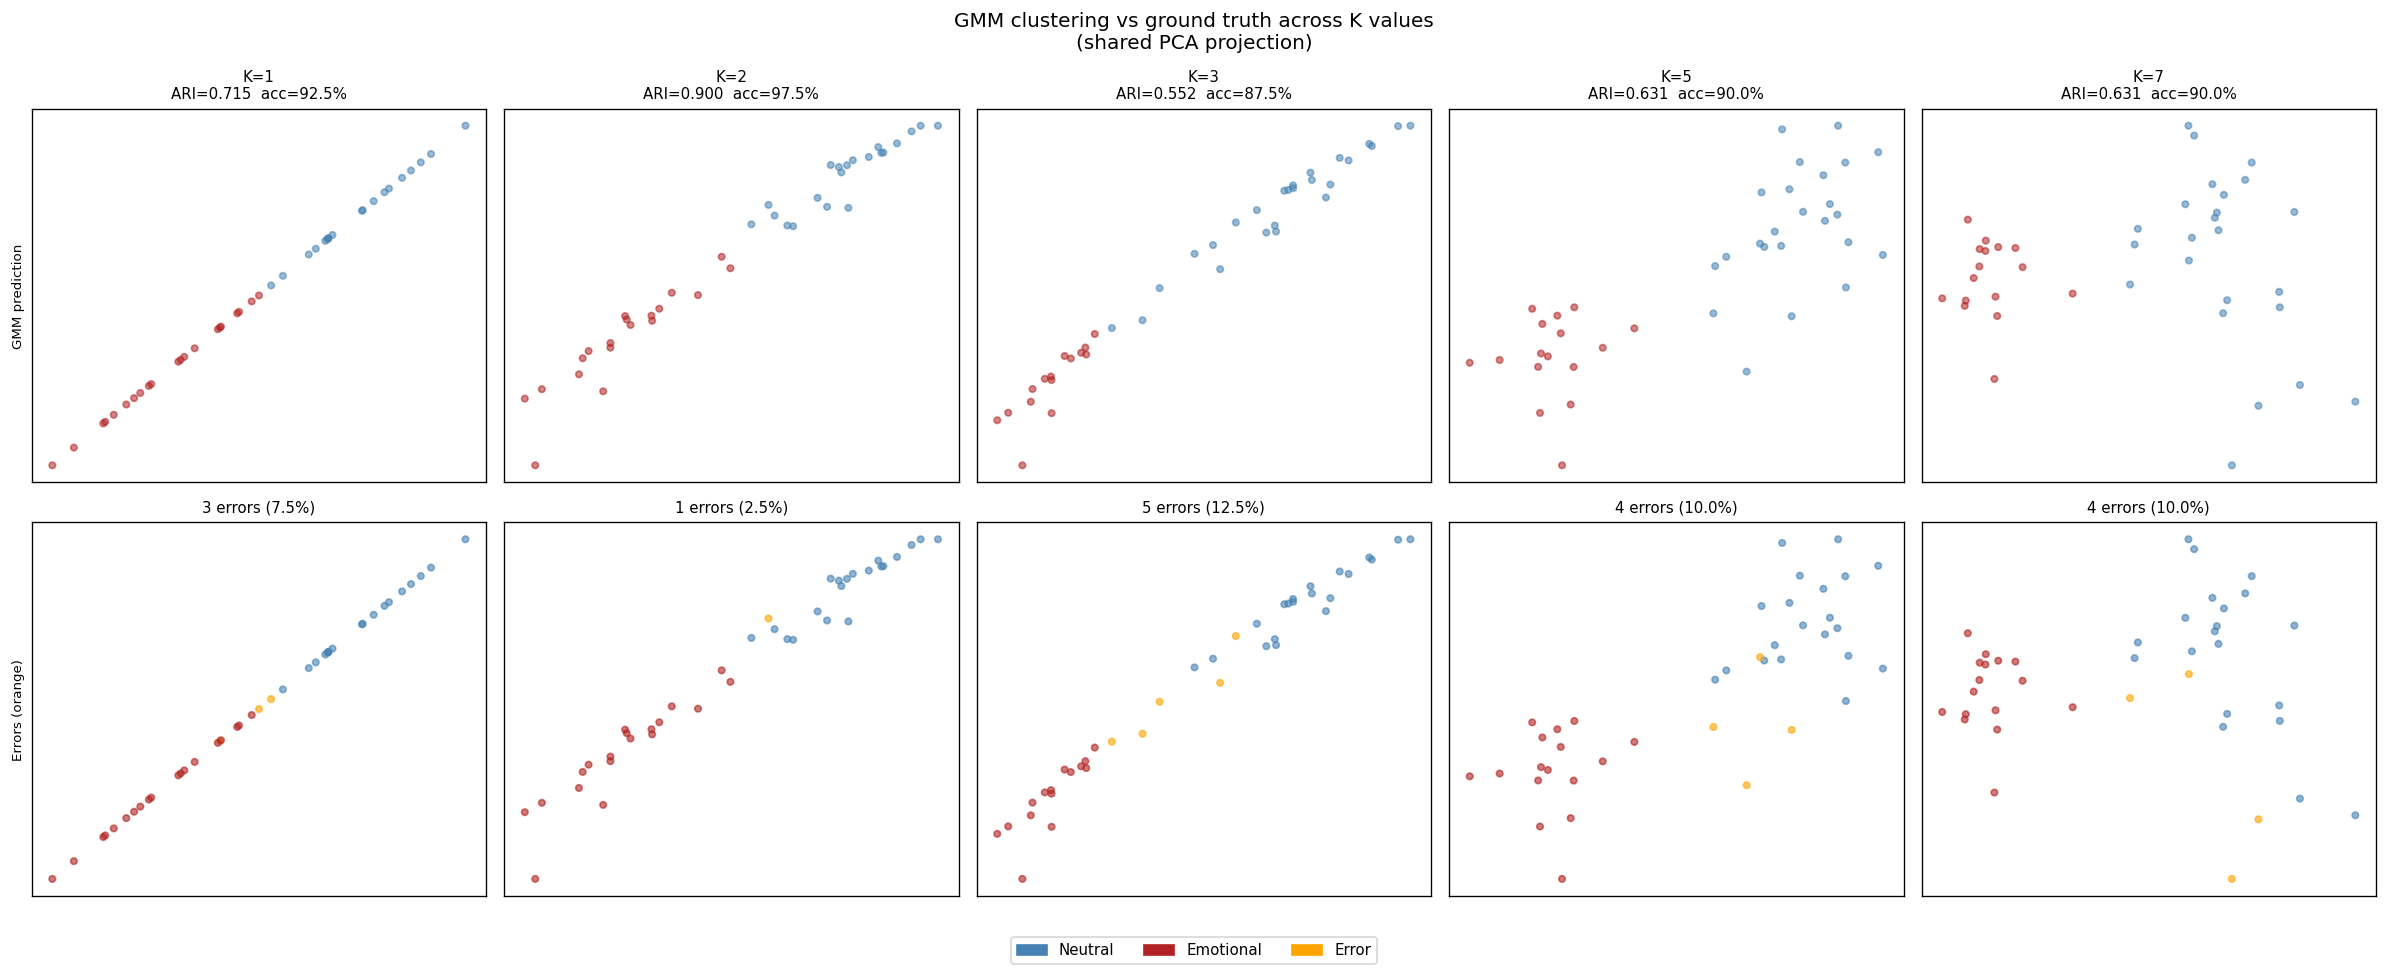

In [19]:
# ── PCA scatter: GMM assignments vs ground truth for multiple K values ──
# Visualise how cluster separation evolves as we add more features.
# Each panel shows GMM prediction at that K, side by side with ground truth errors.

Ks_to_plot = sorted({1, 3, 5, best_ari_k, best_acc_k, TOP_K})
Ks_to_plot = [k for k in Ks_to_plot if 1 <= k <= len(feat_cols)]

n_cols = len(Ks_to_plot)
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

# PCA fit on the full top-K feature set for a stable projection across panels
_pca_ref = PCA(n_components=2, random_state=42)
_pca_ref.fit(X[ranking.head(max(Ks_to_plot))['feature'].tolist()].values)

for col_i, k in enumerate(Ks_to_plot):
    feats_k = ranking.head(k)['feature'].tolist()
    Xk = X[feats_k].values
    gk = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=10)
    lbl_k = gk.fit_predict(Xk)
    # Align orientation
    if (1 - lbl_k == y).mean() > (lbl_k == y).mean():
        lbl_k = 1 - lbl_k
    ari_k  = adjusted_rand_score(y, lbl_k)
    acc_k  = (lbl_k == y).mean()

    # Project onto shared PCA space (pad with zeros if k < max_K)
    Xk_padded = np.zeros((len(Xk), max(Ks_to_plot)))
    Xk_padded[:, :k] = Xk
    coords = _pca_ref.transform(Xk_padded)

    # Top row: GMM prediction coloured by predicted cluster
    ax_top = axes[0, col_i]
    pred_colors = ['steelblue' if l == 0 else 'firebrick' for l in lbl_k]
    ax_top.scatter(coords[:, 0], coords[:, 1], c=pred_colors, alpha=0.55, s=15)
    ax_top.set_title(f'K={k}\nARI={ari_k:.3f}  acc={acc_k:.1%}', fontsize=9)
    if col_i == 0:
        ax_top.set_ylabel('GMM prediction', fontsize=8)
    ax_top.set_xticks([]); ax_top.set_yticks([])

    # Bottom row: errors highlighted
    ax_bot = axes[1, col_i]
    correct_k = lbl_k == y
    err_colors = []
    for gi, yi, ci in zip(lbl_k, y, correct_k):
        if ci:
            err_colors.append('steelblue' if yi == 0 else 'firebrick')
        else:
            err_colors.append('orange')
    ax_bot.scatter(coords[:, 0], coords[:, 1], c=err_colors, alpha=0.6, s=15)
    n_err = (~correct_k).sum()
    ax_bot.set_title(f'{n_err} errors ({n_err/len(y):.1%})', fontsize=9)
    if col_i == 0:
        ax_bot.set_ylabel('Errors (orange)', fontsize=8)
    ax_bot.set_xticks([]); ax_bot.set_yticks([])

from matplotlib.patches import Patch
leg_handles = [Patch(color='steelblue', label='Neutral'),
               Patch(color='firebrick', label='Emotional'),
               Patch(color='orange',    label='Error')]
fig.legend(handles=leg_handles, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('GMM clustering vs ground truth across K values\n(shared PCA projection)',
             fontsize=12)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


## 12 — Feature correlation matrix (top features)

Identify redundant features. Correlated features (|r|>0.9) carry overlapping information
and should be pruned to one representative per cluster.

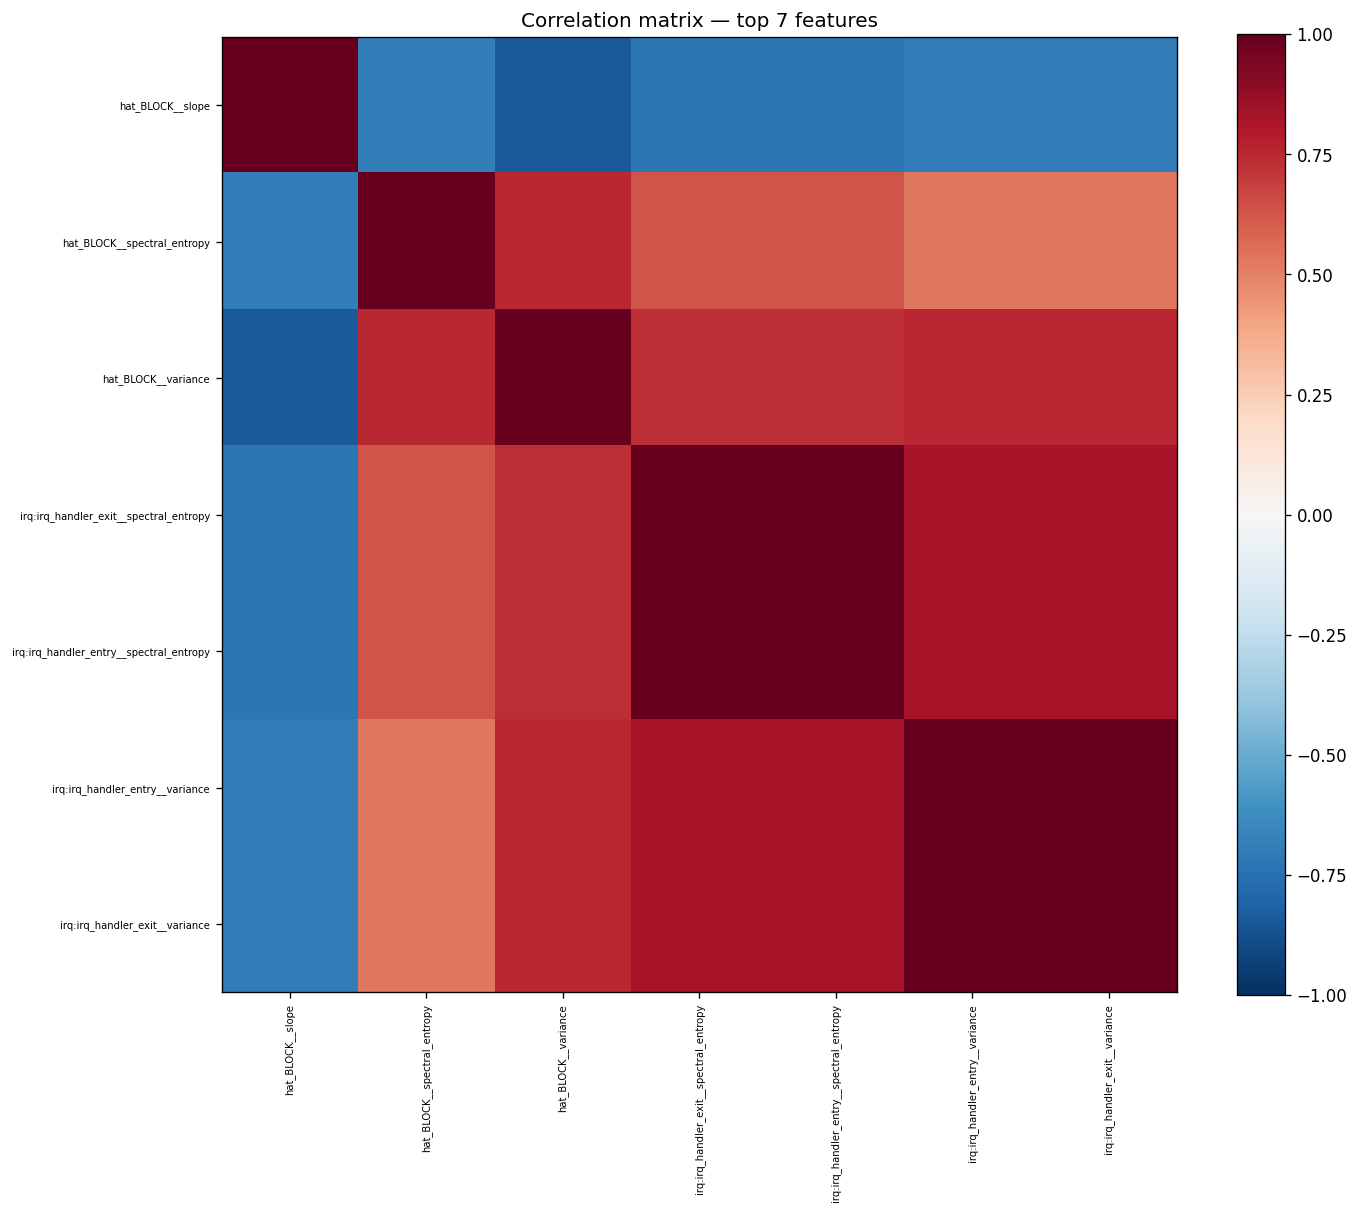

Highly correlated pairs (|r|>0.9): 2
                             feature_A                               feature_B     r
irq:irq_handler_exit__spectral_entropy irq:irq_handler_entry__spectral_entropy 1.000
       irq:irq_handler_entry__variance          irq:irq_handler_exit__variance 1.000


In [20]:
CORR_TOP = min(30, len(top_features))
corr = X[ranking.head(CORR_TOP)['feature'].tolist()].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(CORR_TOP))
ax.set_yticks(range(CORR_TOP))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticklabels(corr.index, fontsize=6)
ax.set_title(f'Correlation matrix — top {CORR_TOP} features')
plt.tight_layout()
plt.show()

# Report highly correlated pairs
high_corr = []
cols = list(corr.columns)
for i, a in enumerate(cols):
    for j, b in enumerate(cols):
        if j <= i:
            continue
        r = corr.loc[a, b]
        if abs(r) > 0.9:
            high_corr.append({'feature_A': a, 'feature_B': b, 'r': r})
if high_corr:
    print(f'Highly correlated pairs (|r|>0.9): {len(high_corr)}')
    print(pd.DataFrame(high_corr).to_string(index=False, float_format='{:.3f}'.format))
else:
    print('No highly correlated pairs among top features.')

## 13 — Per-indicator: which metrics drive each indicator?

For each HAT indicator, show which of the 10 metrics has the best silhouette.
This tells you not just *that* an indicator differs, but *how* it differs.

=== Best metric per indicator (top 30 by ARI) ===
              indicator           metric    ari    acc
              hat_BLOCK spectral_entropy 0.8051 0.9500
   irq:irq_handler_exit spectral_entropy 0.5513 0.8750
  irq:irq_handler_entry spectral_entropy 0.5513 0.8750
          tlb:tlb_flush         variance 0.2305 0.7500
                hat_TLB       burst_rate 0.1023 0.6750
      power/energy-ram/       burst_rate 0.0999 0.6750
    branch-instructions     perm_entropy 0.0748 0.6500
             hat_NET_RX            slope 0.0683 0.6500
                hat_RES    lz_complexity 0.0683 0.6500
      irq:softirq_raise          p90_p10 0.0663 0.6500
      power/energy-pkg/            slope 0.0661 0.6500
       cache-references spectral_entropy 0.0661 0.6500
msr/cpu_thermal_margin/ burst_clustering 0.0661 0.6500
                 cycles            slope 0.0661 0.6500
                hat_PMI spectral_entropy 0.0484 0.6250
                hat_NMI spectral_entropy 0.0484 0.6250
               

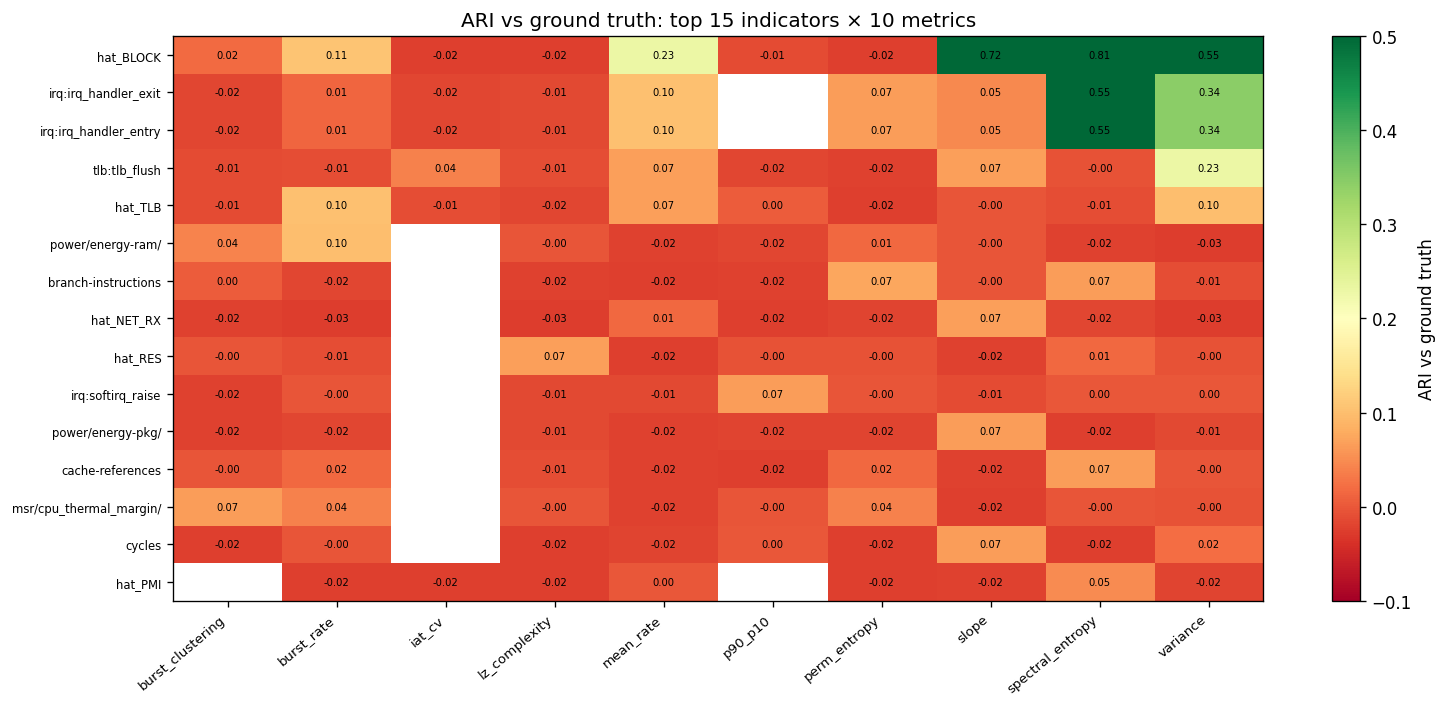

In [21]:
# Parse feature names: indicator__metric
def parse_feature(fname):
    parts = fname.rsplit('__', 1)
    if len(parts) == 2:
        return parts[0], parts[1]
    return fname, ''

clust_df['indicator'] = clust_df.feature.apply(lambda f: parse_feature(f)[0])
clust_df['metric']    = clust_df.feature.apply(lambda f: parse_feature(f)[1])

# Best metric per indicator (by ARI)
best_per_ind = (clust_df
    .sort_values('ari', ascending=False)
    .groupby('indicator')
    .first()
    .reset_index()
    [['indicator', 'metric', 'ari', 'acc']]
    .sort_values('ari', ascending=False)
)

print('=== Best metric per indicator (top 30 by ARI) ===')
print(best_per_ind.head(30).to_string(index=False, float_format='{:.4f}'.format))

# Heatmap: indicators × metrics, ARI value
top_inds = best_per_ind.head(15)['indicator'].tolist()
pivot = clust_df[clust_df.indicator.isin(top_inds)].pivot_table(
    index='indicator', columns='metric', values='ari', aggfunc='first')
pivot = pivot.reindex(index=top_inds)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=-0.1, vmax=0.5, aspect='auto')
plt.colorbar(im, ax=ax, label='ARI vs ground truth')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=40, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([s[:40] for s in pivot.index], fontsize=7)
ax.set_title('ARI vs ground truth: top 15 indicators × 10 metrics')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color='black')
plt.tight_layout()
plt.show()


## 15 — Summary table

The final output: which features survive both univariate screening and clustering,
ranked by composite score. These are the indicators to carry forward.

In [22]:
summary = ranking.copy()
summary['indicator'] = summary.feature.apply(lambda f: parse_feature(f)[0])
summary['metric']    = summary.feature.apply(lambda f: parse_feature(f)[1])

# Flag if length-confounded: metrics NOT normalised by duration
non_normalised = ['variance', 'p90_p10', 'lz_complexity', 'perm_entropy']
summary['length_sensitive'] = summary.metric.isin(non_normalised) & LENGTH_CONFOUNDED

final_cols = ['composite_rank','indicator','metric','p','effect_r','direction',
              'ari','acc','purity','length_sensitive']
print('=== Final metric ranking (top 40) ===')
print(summary.head(40)[final_cols].to_string(index=False, float_format='{:.4f}'.format))


=== Final metric ranking (top 40) ===
 composite_rank               indicator           metric      p  effect_r direction    ari    acc  purity  length_sensitive
         1.5000               hat_BLOCK            slope 0.0000    0.9700        ↑E 0.7152 0.9250  0.9261             False
         1.5000               hat_BLOCK spectral_entropy 0.0000   -0.9550        ↓E 0.8051 0.9500  0.9545             False
         4.0000               hat_BLOCK         variance 0.0000   -0.9150        ↓E 0.5510 0.8750  0.8759             False
         6.2500    irq:irq_handler_exit spectral_entropy 0.0001   -0.7350        ↓E 0.5513 0.8750  0.8836             False
         6.2500   irq:irq_handler_entry spectral_entropy 0.0001   -0.7350        ↓E 0.5513 0.8750  0.8836             False
         6.5000   irq:irq_handler_entry         variance 0.0000   -0.7550        ↓E 0.3433 0.8000  0.8030             False
         6.5000    irq:irq_handler_exit         variance 0.0000   -0.7550        ↓E 0.3433 0.8

## 16 — Diagnosing what 'indicator' actually means in this dataset

**This section is essential to run before any per-indicator clustering.**

The feature column names look like `<indicator>__<metric>` (e.g. `hat_LOC__mean_rate`).
But before treating each unique `indicator` part as a meaningful HAT indicator, we need
to verify the structure is what we expect:

### Expected structure
- ~20 named HAT indicators: `hat_LOC`, `hat_CAL`, `hat_HRTIMER`, `hat_MCP`, `hat_TASKLET`,
  `hat_IWI`, `hat_NMI`, `hat_SCHED`, `hat_RCU`, `hat_BLOCK`, etc. — named softirq/interrupt types
- ~10 perf hardware/software counters: `cache-misses`, `cycles`, `branch-misses`, etc.
- 1 synthetic CPU frequency indicator: `cpu_freq_mean`
- Each of the above should have up to 10 metric columns

### What can go wrong
1. **Numeric IRQ explosion**: `/proc/interrupts` has one row per IRQ number (0–700+).
   If the collector prefixes *every row* with `hat_`, we get hundreds of `hat_0`,
   `hat_120`, `hat_447` ... indicators instead of ~20. This is a naming problem,
   not a data problem.
2. **Metric count mismatch**: Some indicators may only have 1 or 9 metrics instead of 10.
   This happens when `iat_cv` (event-type metric) returns NaN for PCI-type indicators
   and gets dropped by the zero-variance filter in §6.
3. **Duplicate information**: Many numeric IRQ lines in `/proc/interrupts` may belong
   to the same device/driver, so they're not independent indicators.

The cells below print a full audit of what we have.

In [23]:
# Parse feature names: indicator__metric
def parse_feature(fname):
    parts = fname.rsplit('__', 1)
    if len(parts) == 2:
        return parts[0], parts[1]
    return fname, ''

METRIC_NAMES = ['mean_rate','variance','p90_p10','slope','spectral_entropy',
                'iat_cv','burst_rate','burst_clustering','lz_complexity','perm_entropy']

# Build indicator → list of metric columns mapping
# This includes EVERY unique indicator prefix in the feature matrix
from collections import defaultdict
ind_map_raw = defaultdict(list)
for col in feat_cols:
    indicator, metric = parse_feature(col)
    if metric in METRIC_NAMES:
        ind_map_raw[indicator].append(col)
ind_map_raw = dict(ind_map_raw)

print(f'Total indicators found in feature matrix: {len(ind_map_raw)}')
print()

# Categorise each indicator by type
import re

def classify_indicator(name):
    """Classify an indicator name into a category."""
    if re.fullmatch(r'hat_\d+', name):
        return 'numeric_irq'      # e.g. hat_190, hat_447 — raw /proc/interrupts rows
    elif name.startswith('hat_') and name[4:].isupper():
        return 'named_softirq'    # e.g. hat_HRTIMER, hat_LOC, hat_MCP
    elif name.startswith('hat_') and name[4:].isalpha():
        return 'named_softirq'    # e.g. hat_CAL
    elif name.startswith('hat_'):
        return 'hat_other'        # e.g. hat_LOC (mixed)
    elif name == 'cpu_freq_mean':
        return 'cpu_freq'
    else:
        return 'perf_counter'     # e.g. cache-misses, cycles, context-switches

category_counts = defaultdict(int)
for ind in ind_map_raw:
    category_counts[classify_indicator(ind)] += 1

print('=== Indicator categories ===')
for cat, n in sorted(category_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat:20s}: {n:4d} indicators')

print()
print('=== Named softirq / hat indicators (the ~20 we care about) ===')
named = {k: v for k, v in ind_map_raw.items()
         if classify_indicator(k) in ('named_softirq', 'hat_other', 'cpu_freq')}
for ind, cols in sorted(named.items()):
    metrics_present = sorted([parse_feature(c)[1] for c in cols])
    missing = [m for m in METRIC_NAMES if m not in metrics_present]
    flag = '  ← MISSING METRICS: ' + ', '.join(missing) if missing else ''
    print(f'  {ind:20s}: {len(cols):2d} metrics  [{', '.join(metrics_present)}]{flag}')

print()
print('=== Perf hardware/software counters ===')
perf = {k: v for k, v in ind_map_raw.items() if classify_indicator(k) == 'perf_counter'}
for ind, cols in sorted(perf.items()):
    metrics_present = sorted([parse_feature(c)[1] for c in cols])
    missing = [m for m in METRIC_NAMES if m not in metrics_present]
    flag = '  ← MISSING: ' + ', '.join(missing) if missing else ''
    print(f'  {ind:30s}: {len(cols):2d} metrics{flag}')

print()
print('=== Numeric IRQ indicators (first 20 shown) ===')
numeric = {k: v for k, v in ind_map_raw.items() if classify_indicator(k) == 'numeric_irq'}
for ind, cols in sorted(numeric.items(), key=lambda x: int(x[0].split('_')[1]))[:20]:
    metrics_present = sorted([parse_feature(c)[1] for c in cols])
    print(f'  {ind:15s}: {len(cols):2d} metrics  [{', '.join(metrics_present)}]')
print(f'  ... and {len(numeric)-20} more numeric IRQ indicators')

Total indicators found in feature matrix: 53

=== Indicator categories ===
  named_softirq       :   29 indicators
  perf_counter        :   23 indicators
  cpu_freq            :    1 indicators

=== Named softirq / hat indicators (the ~20 we care about) ===
  cpu_freq_mean       :  9 metrics  [burst_clustering, burst_rate, lz_complexity, mean_rate, p90_p10, perm_entropy, slope, spectral_entropy, variance]  ← MISSING METRICS: iat_cv
  hat_BLOCK           : 10 metrics  [burst_clustering, burst_rate, iat_cv, lz_complexity, mean_rate, p90_p10, perm_entropy, slope, spectral_entropy, variance]
  hat_CAL             :  9 metrics  [burst_clustering, burst_rate, lz_complexity, mean_rate, p90_p10, perm_entropy, slope, spectral_entropy, variance]  ← MISSING METRICS: iat_cv
  hat_DFR             :  1 metrics  [lz_complexity]  ← MISSING METRICS: mean_rate, variance, p90_p10, slope, spectral_entropy, iat_cv, burst_rate, burst_clustering, perm_entropy
  hat_ERR             :  1 metrics  [lz_complexi

### Interpretation

The output above will reveal the structure. Here's what each category means:

**`named_softirq`** (e.g. `hat_HRTIMER`, `hat_LOC`, `hat_MCP`, `hat_CAL`, `hat_TASKLET`,
`hat_NMI`, `hat_SCHED`, `hat_RCU`, `hat_BLOCK`, `hat_NET_RX`, `hat_NET_TX`, `hat_IWI`):  
These are rows from `/proc/softirqs` — the actual meaningful high-level interrupt categories
in the Linux kernel. These are what a HAT thesis would treat as distinct indicators.
**These are the ~10–20 we want.**

**`numeric_irq`** (e.g. `hat_190`, `hat_447`, `hat_603`):  
These are *individual hardware IRQ lines* from `/proc/interrupts`. Linux assigns a numeric
ID to every physical interrupt source (NIC, NVME, USB controller, etc.). A modern server
can have 600+ of these. They are **not** independent HAT indicators — they are lower-level
than the softirq mechanism and many correspond to the same device.

**`perf_counter`** (e.g. `cache-misses`, `cycles`, `dTLB-load-misses`):  
These are perf PMU hardware/software counters. Each is a valid HAT PCI indicator.

### The fix
For the per-indicator analysis, we define **two views**:

1. **`ind_map_named`**: only named softirq + perf counters + cpu_freq — the ~20–25
   semantically meaningful indicators your thesis uses.
2. **`ind_map_all`**: everything including numeric IRQs — used for completeness but
   results are expected to be highly redundant.

Going forward, the main analysis uses `ind_map_named`.

In [24]:
# Build the two indicator maps
NAMED_CATEGORIES = {'named_softirq', 'hat_other', 'cpu_freq', 'perf_counter'}

ind_map_named = {k: v for k, v in ind_map_raw.items()
                 if classify_indicator(k) in NAMED_CATEGORIES}
ind_map_all   = ind_map_raw  # full map including numeric IRQs

print(f'Named/semantic indicators: {len(ind_map_named)}')
print(f'All indicators (incl. numeric IRQs): {len(ind_map_all)}')
print()
print('Named indicators and their metric counts:')
for ind, cols in sorted(ind_map_named.items()):
    n_metrics = len(cols)
    metrics = sorted([parse_feature(c)[1] for c in cols])
    print(f'  {ind:30s}: {n_metrics:2d} metrics')

print()
print('NOTE: Expected 10 metrics each. If any show <10, check which ones are missing above.')
print('  iat_cv is intentionally NaN for PCIs (perf counters sampled at fixed interval).')
print('  If it is also missing for named softirqs (event-indicators), that is a bug.')

Named/semantic indicators: 53
All indicators (incl. numeric IRQs): 53

Named indicators and their metric counts:
  LLC-load-misses               :  9 metrics
  branch-instructions           :  9 metrics
  branch-misses                 :  9 metrics
  cache-misses                  :  9 metrics
  cache-references              :  9 metrics
  context-switches              :  9 metrics
  core_power.throttle           :  9 metrics
  cpu-clock                     :  9 metrics
  cpu-migrations                :  9 metrics
  cpu_freq_mean                 :  9 metrics
  cycles                        :  9 metrics
  dTLB-load-misses              :  9 metrics
  hat_BLOCK                     : 10 metrics
  hat_CAL                       :  9 metrics
  hat_DFR                       :  1 metrics
  hat_ERR                       :  1 metrics
  hat_HI                        :  1 metrics
  hat_HRTIMER                   :  1 metrics
  hat_IRQ_POLL                  :  1 metrics
  hat_IWI                       

## 18 — Per-indicator, per-metric clustering (the full grid)

Now the finest granularity: for every **(indicator, metric) pair**, we cluster
on that single scalar alone and score against the ground truth.

This is the most interpretable output: it says exactly *which measurement*
of *which indicator* drives the separation.

### Column meaning
- `gmm_ari` / `gmm_acc`: clustering quality for this specific (indicator, metric) cell
- `gmm_n_acc` / `gmm_e_acc`: per-condition accuracy within this cell
- `p`, `effect_r`: Mann-Whitney U p-value and rank-biserial r from §7
- `direction`: ↑E = higher in emotional, ↓E = lower in emotional

### Relationship between ARI and p-value
- High ARI + low p: the feature both statistically differs and geometrically separates — strongest evidence
- High ARI + high p: clusters are geometrically distinct but distributions overlap a lot (unusual)
- Low ARI + low p: statistically significant shift but insufficient to fully separate into two clusters
- Low ARI + high p: no signal — uninteresting indicator/metric combination

In [27]:

def cluster_and_score(x1d, y, indicator_name, n_init=10, random_state=42):
    """
    Cluster a single 1-D feature with both GMM and KMeans (k=2),
    align predicted labels to ground truth, and return a results dict.

    Parameters
    ----------
    x1d            : (n, 1) float array — raw feature values
    y              : (n,)   int array   — ground truth (0=neutral, 1=emotional)
    indicator_name : str                — stored in the output dict
    n_init         : int                — GMM/KMeans restarts
    random_state   : int

    Returns
    -------
    dict with keys:
        indicator, n_samples,
        gmm_ari, gmm_acc, gmm_n_acc, gmm_e_acc,
        km_ari,  km_acc
    """
    from sklearn.preprocessing import StandardScaler
    from sklearn.mixture import GaussianMixture
    from sklearn.cluster import KMeans
    from sklearn.metrics import adjusted_rand_score

    result = dict(indicator=indicator_name)

    # Drop NaN / Inf rows
    mask = np.isfinite(x1d).ravel()
    Xc = x1d[mask]
    yc = y[mask]
    result['n_samples'] = int(mask.sum())

    if mask.sum() < 10 or len(np.unique(yc)) < 2:
        for key in ('gmm_ari','gmm_acc','gmm_n_acc','gmm_e_acc','km_ari','km_acc'):
            result[key] = np.nan
        return result

    # Standardise
    sc = StandardScaler()
    Xs = sc.fit_transform(Xc)

    def _align_and_score(lbl, gt):
        """Flip labels if that improves accuracy, return ari, acc, n_acc, e_acc."""
        acc_d = (lbl == gt).mean()
        acc_f = (1 - lbl == gt).mean()
        if acc_f > acc_d:
            lbl = 1 - lbl
        ari   = adjusted_rand_score(gt, lbl)
        acc   = (lbl == gt).mean()
        n_acc = (lbl[gt == 0] == 0).mean() if (gt == 0).sum() > 0 else np.nan
        e_acc = (lbl[gt == 1] == 1).mean() if (gt == 1).sum() > 0 else np.nan
        return ari, acc, n_acc, e_acc

    # ── GMM ──────────────────────────────────────────────────────────
    try:
        gmm = GaussianMixture(n_components=2, covariance_type='full',
                              random_state=random_state, n_init=n_init)
        lbl_gmm = gmm.fit_predict(Xs)
        ari, acc, n_acc, e_acc = _align_and_score(lbl_gmm, yc)
        result.update(gmm_ari=ari, gmm_acc=acc, gmm_n_acc=n_acc, gmm_e_acc=e_acc)
    except Exception:
        result.update(gmm_ari=np.nan, gmm_acc=np.nan, gmm_n_acc=np.nan, gmm_e_acc=np.nan)

    # ── KMeans ───────────────────────────────────────────────────────
    try:
        km = KMeans(n_clusters=2, random_state=random_state, n_init=n_init)
        lbl_km = km.fit_predict(Xs)
        km_ari, km_acc, _, _ = _align_and_score(lbl_km, yc)
        result.update(km_ari=km_ari, km_acc=km_acc)
    except Exception:
        result.update(km_ari=np.nan, km_acc=np.nan)

    return result

print('cluster_and_score defined.')


cluster_and_score defined.


In [28]:
print('Running per-indicator × per-metric clustering...')
print(f'This will process {sum(len(v) for v in ind_map_named.values())} (indicator, metric) cells')
print()

per_cell_results = []
for indicator, cols in sorted(ind_map_named.items()):
    indicator_results = []
    for col in cols:
        _, metric = parse_feature(col)
        x1d = X_raw[[col]].values.astype(float)
        res = cluster_and_score(x1d, y, indicator)
        res['metric']  = metric
        res['feature'] = col
        per_cell_results.append(res)
        indicator_results.append((metric, res.get('gmm_ari', np.nan), res.get('gmm_acc', np.nan)))
    
    # Print a one-line summary per indicator showing all metrics
    print(f'  {indicator:30s}:')
    for metric, ari, acc in sorted(indicator_results, key=lambda x: -(x[1] or -1)):
        if np.isnan(ari):
            print(f'    {metric:20s}: SKIP')
        else:
            bar = '█' * int(max(0, ari) * 15)
            print(f'    {metric:20s}: ARI={ari:.3f}  acc={acc:.1%}  {bar}')

cell_df = pd.DataFrame(per_cell_results)
print(f'\nTotal cells computed: {len(cell_df)}')

Running per-indicator × per-metric clustering...
This will process 342 (indicator, metric) cells

  LLC-load-misses               :
    burst_rate          : ARI=0.019  acc=60.0%  
    slope               : ARI=0.015  acc=57.5%  
    lz_complexity       : ARI=-0.003  acc=55.0%  
    burst_clustering    : ARI=-0.009  acc=52.5%  
    variance            : ARI=-0.009  acc=50.0%  
    p90_p10             : ARI=-0.009  acc=50.0%  
    perm_entropy        : ARI=-0.015  acc=55.0%  
    spectral_entropy    : ARI=-0.016  acc=55.0%  
    mean_rate           : ARI=-0.020  acc=52.5%  
  branch-instructions           :
    perm_entropy        : ARI=0.075  acc=65.0%  █
    slope               : ARI=0.021  acc=60.0%  
    lz_complexity       : ARI=-0.007  acc=55.0%  
    variance            : ARI=-0.009  acc=52.5%  
    burst_clustering    : ARI=-0.013  acc=50.0%  
    burst_rate          : ARI=-0.016  acc=55.0%  
    mean_rate           : ARI=-0.024  acc=50.0%  
    p90_p10             : ARI=-0.025 

In [29]:
# Merge with MWU statistics from §7
cell_df = cell_df.merge(
    mwu_df[['feature','p','effect_r','direction']],
    on='feature', how='left'
)

cell_df_sorted = cell_df.sort_values('gmm_ari', ascending=False).reset_index(drop=True)

print('=== Top 30 (indicator, metric) cells by GMM ARI ===')
print('Interpretation: sorted by how well a SINGLE metric on a SINGLE indicator')
print('clusters the 240 trials into their correct neutral/emotional groups.')
print()
show = ['indicator','metric','gmm_ari','gmm_acc','gmm_n_acc','gmm_e_acc','p','effect_r','direction']
print(cell_df_sorted.head(30)[show].to_string(index=False, float_format='{:.4f}'.format))

print()
print('=== Bottom 10 (indicator, metric) cells — near-zero ARI ===')
print('These metrics provide essentially no separation for their indicator.')
cell_bottom = cell_df_sorted[cell_df_sorted.gmm_ari.notna()].tail(10)
print(cell_bottom[show].to_string(index=False, float_format='{:.4f}'.format))

cell_df_sorted.to_csv(BASE_DIR / 'per_indicator_per_metric.csv', index=False)
print(f'\nSaved → {BASE_DIR}/per_indicator_per_metric.csv')

=== Top 30 (indicator, metric) cells by GMM ARI ===
Interpretation: sorted by how well a SINGLE metric on a SINGLE indicator
clusters the 240 trials into their correct neutral/emotional groups.

            indicator           metric  gmm_ari  gmm_acc  gmm_n_acc  gmm_e_acc      p  effect_r direction
            hat_BLOCK            slope   0.7152   0.9250     0.9000     0.9500 0.0000    0.9700        ↑E
irq:irq_handler_entry spectral_entropy   0.5513   0.8750     0.9500     0.8000 0.0001   -0.7350        ↓E
 irq:irq_handler_exit spectral_entropy   0.5513   0.8750     0.9500     0.8000 0.0001   -0.7350        ↓E
            hat_BLOCK         variance   0.4778   0.8500     1.0000     0.7000 0.0000   -0.9150        ↓E
 irq:irq_handler_exit         variance   0.4771   0.8500     0.9500     0.7500 0.0000   -0.7550        ↓E
irq:irq_handler_entry         variance   0.4771   0.8500     0.9500     0.7500 0.0000   -0.7550        ↓E
            hat_BLOCK spectral_entropy   0.3447   0.8000     0.

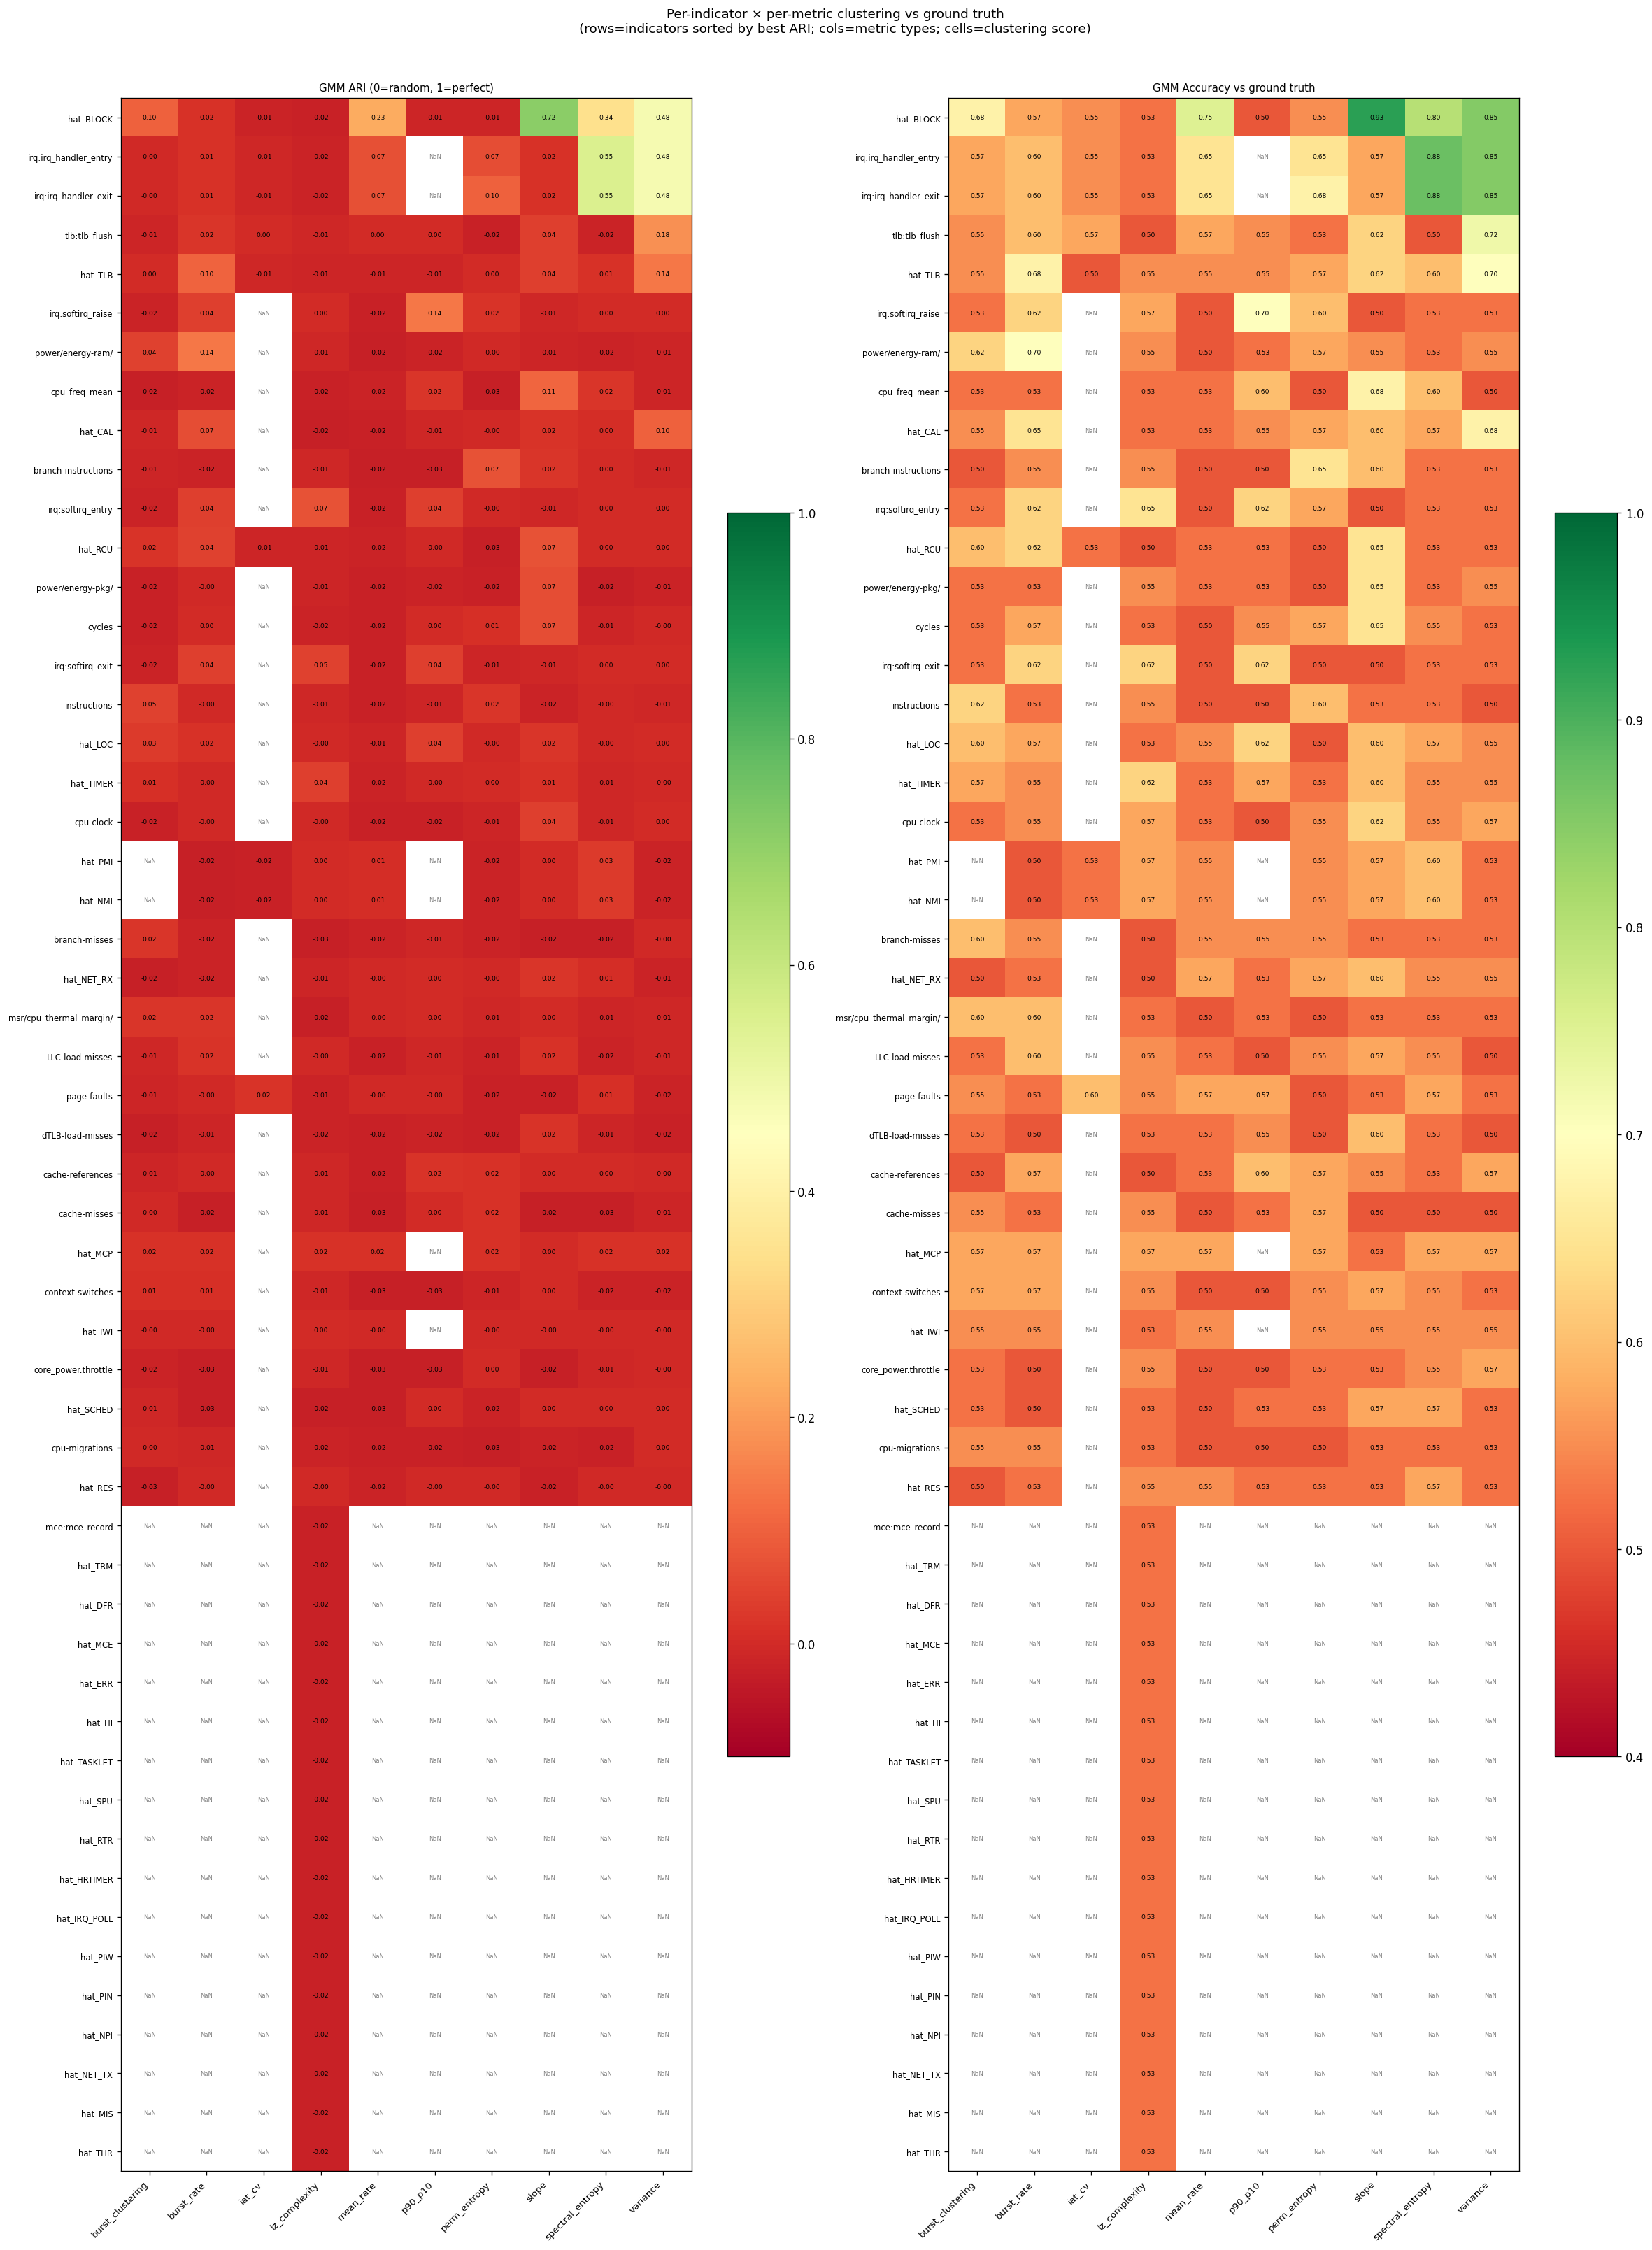

In [30]:
# ── Heatmap: indicators × metrics, coloured by GMM ARI ──
# Use named indicators only
all_named_inds = sorted(ind_map_named.keys())

# Sort rows by best single-metric ARI (most discriminative indicator on top)
best_ari_per_ind = (
    cell_df.groupby('indicator')['gmm_ari']
    .max().sort_values(ascending=False)
)
ordered_inds = best_ari_per_ind.index.tolist()

pivot_ari = cell_df.pivot_table(
    index='indicator', columns='metric', values='gmm_ari', aggfunc='first'
).reindex(index=ordered_inds)

pivot_acc = cell_df.pivot_table(
    index='indicator', columns='metric', values='gmm_acc', aggfunc='first'
).reindex(index=ordered_inds)

fig, axes = plt.subplots(1, 2, figsize=(20, max(8, len(ordered_inds) * 0.5)))

for ax, pivot, title, vmin, vmax, cmap in [
    (axes[0], pivot_ari, 'GMM ARI (0=random, 1=perfect)',   -0.1, 1.0, 'RdYlGn'),
    (axes[1], pivot_acc, 'GMM Accuracy vs ground truth',     0.4,  1.0, 'RdYlGn'),
]:
    im = ax.imshow(pivot.values.astype(float), cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.6)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=7)
    ax.set_title(title, fontsize=9)
    # Annotate each cell
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=5.5, color='black')
            else:
                ax.text(j, i, 'NaN', ha='center', va='center',
                        fontsize=5, color='gray')

plt.suptitle(
    'Per-indicator × per-metric clustering vs ground truth\n'
    '(rows=indicators sorted by best ARI; cols=metric types; cells=clustering score)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.show()

## 20 — Confusion matrices for the top (indicator, metric) pairs

For the top N cells by GMM ARI, we show the full 2×2 confusion matrix:

```
              Cluster 0    Cluster 1
Neutral (GT)    TP_n         FN_n
Emotional(GT)   FN_e         TP_e
```

A perfect result has zeros on the off-diagonal. An asymmetric result reveals which
condition is harder to assign. This is the **most honest diagnostic** — it shows
whether the clustering recovers the actual experimental design.

NameError: name 'confusion_matrix' is not defined

NameError: name 'confusion_matrix' is not defined

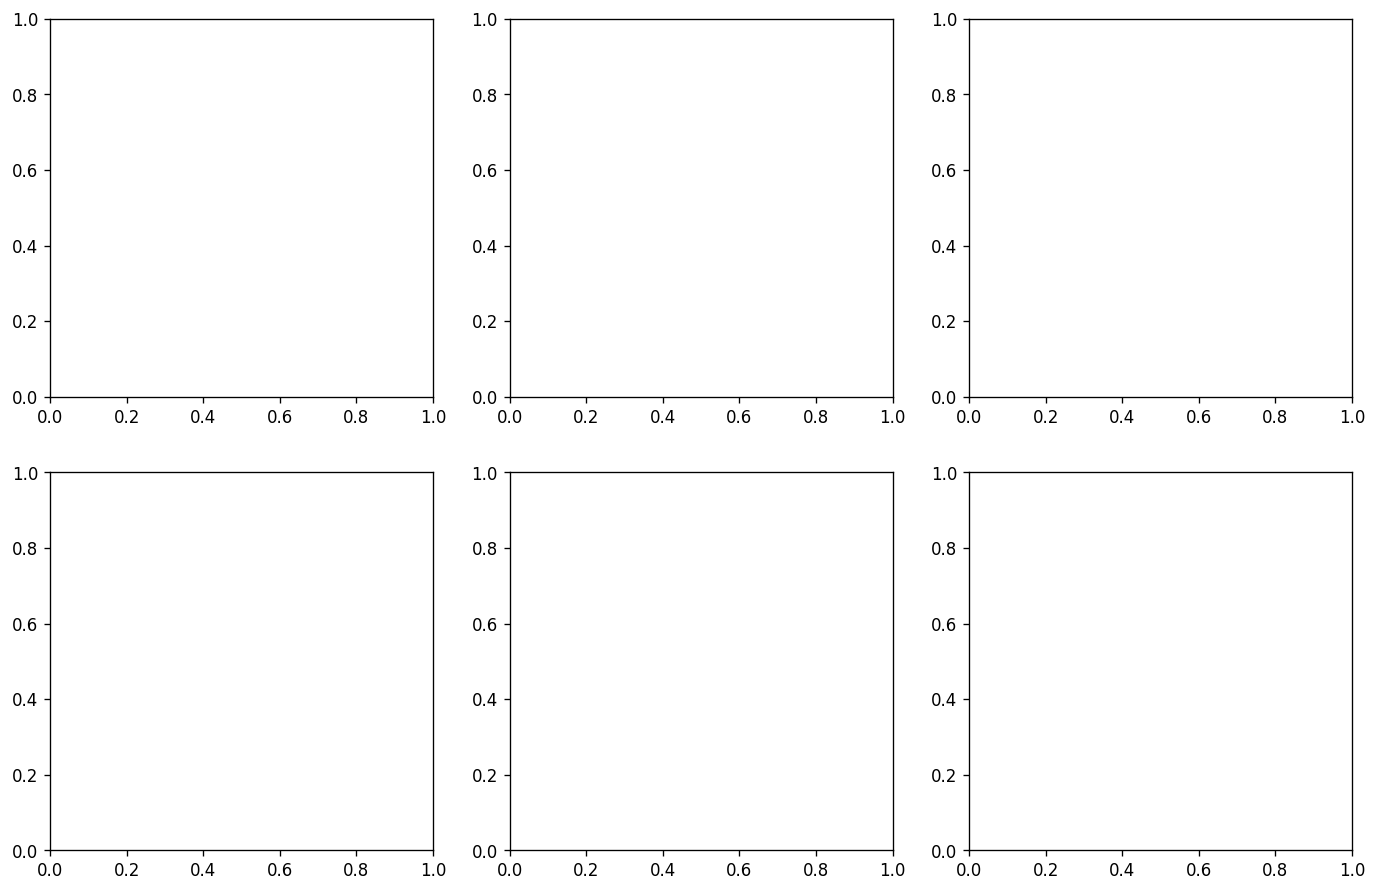

In [31]:
TOP_CM = 6
top_cells = cell_df_sorted.dropna(subset=['gmm_ari']).head(TOP_CM)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for i, (_, row) in enumerate(top_cells.iterrows()):
    ax = axes[i]
    col = row['feature']

    x1d = X_raw[[col]].values.astype(float)
    mask = np.isfinite(x1d).ravel()
    Xc = x1d[mask]; yc = y[mask]

    sc = StandardScaler()
    Xs = sc.fit_transform(Xc)
    gmm_m = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=10)
    lbl = gmm_m.fit_predict(Xs)

    # Align orientation
    if (1 - lbl == yc).mean() > (lbl == yc).mean():
        lbl = 1 - lbl

    cm = confusion_matrix(yc, lbl)
    # Rows: true label (0=neutral, 1=emotional); Cols: predicted cluster
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, shrink=0.7)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Cluster 0\n(pred. Neutral)', 'Cluster 1\n(pred. Emotional)'], fontsize=7)
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Neutral\n(GT)', 'Emotional\n(GT)'], fontsize=7)

    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r, c] > cm.max() * 0.5 else 'black')

    acc = (lbl == yc).mean()
    n_err = cm[0, 1]  # neutral assigned to emotional cluster
    e_err = cm[1, 0]  # emotional assigned to neutral cluster
    ax.set_title(
        f'{row["indicator"]}\nmetric: {row["metric"]}\n'
        f'ARI={row["gmm_ari"]:.3f}  acc={acc:.1%}  '
        f'errors: {n_err}N+{e_err}E',
        fontsize=7
    )

plt.suptitle(f'Confusion matrices — top {TOP_CM} (indicator, metric) pairs by GMM ARI\n'
             'Diagonal = correctly assigned; off-diagonal = errors',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()
print('Zero off-diagonal = perfect separation.')

## 21 — Final results table & key findings

The unified results table for thesis reporting. Every (indicator, metric) pair,
with all scores, statistics, and a `length_sensitive` flag.

### Length confound reminder
Neutral trials are significantly shorter than emotional (`LENGTH_CONFOUNDED=True`).
Some metrics that scale with duration (not normalised by `dur_s`) may be detecting
**length**, not **emotional content**. These are flagged `length_sensitive=True`.

- **Safe** (normalised): `mean_rate`, `burst_rate` — divided by `dur_s`
- **Safe** (intrinsic): `slope`, `spectral_entropy`, `iat_cv` — shape features
- **Suspect** (not normalised): `variance`, `p90_p10`, `lz_complexity`, `perm_entropy` —
  longer series have higher variance and complexity by construction

**If a length-sensitive metric shows high ARI, treat the result with caution** unless
you control for `elapsed_ms` (e.g. by residualising or using matched-duration subsets).

In [ ]:
final = cell_df_sorted[[
    'indicator','metric','feature',
    'gmm_ari','gmm_acc','gmm_n_acc','gmm_e_acc',
    'km_ari','km_acc',
    'p','effect_r','direction','n_samples'
]].copy()

non_normalised = ['variance', 'p90_p10', 'lz_complexity', 'perm_entropy']
final['length_sensitive'] = final.metric.isin(non_normalised) & LENGTH_CONFOUNDED

# Print split by length-sensitivity
safe    = final[~final.length_sensitive].dropna(subset=['gmm_ari'])
suspect = final[final.length_sensitive].dropna(subset=['gmm_ari'])

print('=== TOP 20 SAFE metrics (not length-sensitive), sorted by GMM ARI ===')
print('These are the strongest findings not confounded by prompt duration.')
print()
print(safe.head(20)[['indicator','metric','gmm_ari','gmm_acc','gmm_n_acc','gmm_e_acc',
                      'p','effect_r','direction']]
      .to_string(index=False, float_format='{:.4f}'.format))

print()
print('=== TOP 20 LENGTH-SENSITIVE metrics (interpret with caution) ===')
print('These may be detecting prompt length rather than emotional content.')
print()
print(suspect.head(20)[['indicator','metric','gmm_ari','gmm_acc','gmm_n_acc','gmm_e_acc',
                         'p','effect_r','direction']]
      .to_string(index=False, float_format='{:.4f}'.format))

print()
print('=== KEY FINDINGS (safe metrics only, ARI > 0.05) ===')
key = safe[safe.gmm_ari > 0.05].head(10)
for _, r in key.iterrows():
    print(f'  {r.indicator:30s} × {r.metric:20s}:  '
          f'ARI={r.gmm_ari:.3f}  acc={r.gmm_acc:.1%}  '
          f'p={r.p:.2e}  {r.direction}')


=== TOP 20 SAFE metrics (not length-sensitive), sorted by GMM ARI ===
These are the strongest findings not confounded by prompt duration.

          indicator           metric  gmm_ari  gmm_acc  gmm_n_acc  gmm_e_acc      p  effect_r direction
   dTLB-load-misses         variance   0.2386   0.7458     0.7083     0.7833 0.0000   -0.6631        ↓E
         hat_NET_RX         variance   0.1374   0.6875     0.5250     0.8500 0.0000   -0.5257        ↓E
            hat_RCU        mean_rate   0.1370   0.6875     0.6833     0.6917 0.0000   -0.3601        ↓E
  irq:softirq_entry         variance   0.1022   0.6625     0.5167     0.8083 0.0000   -0.3472        ↓E
   irq:softirq_exit         variance   0.1022   0.6625     0.5167     0.8083 0.0000   -0.3469        ↓E
  irq:softirq_raise         variance   0.0968   0.6583     0.5167     0.8000 0.0000   -0.3475        ↓E
        page-faults    lz_complexity   0.0867   0.6500     0.4583     0.8417 0.0000   -0.3695        ↓E
       instructions         v

# TEST time

In [35]:

# ══════════════════════════════════════════════════════════════════════
# TEST SET EVALUATION — CLtestE + CLtestN
# 1-feature GMM for top-10 safe features; visualise top-3 by ARI+acc
# ══════════════════════════════════════════════════════════════════════

from sklearn.linear_model import LinearRegression as _LR
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from matplotlib.patches import Patch

_node   = 'clemsonc6420'
_ddir   = BASE_DIR / 'data' / _node

df_test = pd.concat([pd.read_csv(_ddir / 'CLtestE.csv'),
                     pd.read_csv(_ddir / 'CLtestN.csv')], ignore_index=True)
y_test  = (df_test['condition'] == 'emotional').astype(int).values

print(f'Test set: {len(df_test)} trials  '
      f'(neutral={(df_test.condition=="neutral").sum()}, '
      f'emotional={(df_test.condition=="emotional").sum()})')
print(f'Test elapsed_ms:     mean={df_test.elapsed_ms.mean():.0f}  '
      f'median={df_test.elapsed_ms.median():.0f}')
print(f'Training elapsed_ms: mean={df_all.elapsed_ms.mean():.0f}  '
      f'median={df_all.elapsed_ms.median():.0f}')

# ── Build raw test feature matrix — only columns present in BOTH sets ─
avail_feat_cols = [c for c in feat_cols if c in df_test.columns]
missing_cols    = [c for c in feat_cols if c not in df_test.columns]
print(f'\nFeature columns: {len(avail_feat_cols)} available, '
      f'{len(missing_cols)} missing from test data (dropped)')

train_medians = X_raw[avail_feat_cols].median()
test_raw = df_test[avail_feat_cols].copy().fillna(train_medians)

# ── Residualise elapsed_ms (training coefficients applied to test) ────
print('\nFitting elapsed_ms residualisation on training data…')
elapsed_train = df_all[['elapsed_ms']].values.astype(float)
elapsed_test  = df_test[['elapsed_ms']].values.astype(float)

X_raw_resid    = X_raw[avail_feat_cols].copy()
test_raw_resid = test_raw.copy()

for _col in avail_feat_cols:
    yr_  = X_raw[_col].values.astype(float)
    msk  = np.isfinite(yr_) & np.isfinite(elapsed_train.ravel())
    if msk.sum() < 10:
        continue
    _reg = _LR().fit(elapsed_train[msk], yr_[msk])
    X_raw_resid[_col]    = yr_ - _reg.predict(elapsed_train)
    test_raw_resid[_col] = test_raw[_col].values - _reg.predict(elapsed_test)

print('Done.')

# ── Top-10 safe features (from available cols, not length-confounded) ─
safe_avail_cols = [c for c in avail_feat_cols
                   if c.split('__', 1)[-1] not in LENGTH_CONFOUNDED_METRICS]
_safe_ranking   = ranking[ranking['feature'].isin(safe_avail_cols)].copy()
top10_safe      = _safe_ranking.head(10)['feature'].tolist()

print(f'\nTop-10 safe features (available in test):')
for _f in top10_safe:
    print(f'  {_f}')

# ══════════════════════════════════════════════════════════════════════
# Evaluate each feature individually (1-feat GMM)
# ══════════════════════════════════════════════════════════════════════
def _eval_1feat(feat_name, train_df, test_df, y_tr, y_te, n_init=20):
    sc   = StandardScaler()
    Xtr_ = sc.fit_transform(train_df[[feat_name]].fillna(0))
    Xte_ = sc.transform(test_df[[feat_name]].fillna(0))

    g = GaussianMixture(n_components=2, covariance_type='full',
                        random_state=42, n_init=n_init)
    g.fit(Xtr_)
    lbl_tr_ = g.predict(Xtr_)
    flip = (1 - lbl_tr_ == y_tr).mean() > (lbl_tr_ == y_tr).mean()

    lbl_te_ = g.predict(Xte_)
    if flip:
        lbl_te_ = 1 - lbl_te_

    ari_   = adjusted_rand_score(y_te, lbl_te_)
    acc_   = (lbl_te_ == y_te).mean()
    n_acc_ = (lbl_te_[y_te == 0] == 0).mean() if (y_te == 0).sum() > 0 else np.nan
    e_acc_ = (lbl_te_[y_te == 1] == 1).mean() if (y_te == 1).sum() > 0 else np.nan

    pca_tr_ = np.column_stack([Xtr_, np.zeros(len(Xtr_))])
    pca_te_ = np.column_stack([Xte_, np.zeros(len(Xte_))])

    return dict(feat=feat_name, ari=ari_, acc=acc_,
                n_acc=n_acc_, e_acc=e_acc_, lbl_te=lbl_te_,
                pca_tr=pca_tr_, pca_te=pca_te_, flip=flip)

# Run both views (safe raw + residualised) for each feature
X_raw_avail = X_raw[avail_feat_cols]

print('\n' + '─'*72)
print(f'{"Feature":<42}  {"ARI":>6}  {"acc":>6}  {"N-acc":>6}  {"E-acc":>6}  view')
print('─'*72)

all_results = []
for _f in top10_safe:
    for _view, _tr, _te in [('safe',  X_raw_avail,  test_raw),
                             ('resid', X_raw_resid,  test_raw_resid)]:
        r = _eval_1feat(_f, _tr, _te, y, y_test)
        r['view'] = _view
        all_results.append(r)
        print(f'{_f:<42}  {r["ari"]:6.3f}  {r["acc"]:6.1%}  '
              f'{r["n_acc"]:6.1%}  {r["e_acc"]:6.1%}  {_view}')

# ══════════════════════════════════════════════════════════════════════
# Pick top-3 to visualise (by ARI desc, then acc desc)
# ══════════════════════════════════════════════════════════════════════
import pandas as _pd2
res_df = _pd2.DataFrame([{k: v for k, v in r.items()
                           if k not in ('lbl_te', 'pca_tr', 'pca_te')}
                          for r in all_results])

res_df_sorted = res_df.sort_values(['ari', 'acc'], ascending=False).reset_index(drop=True)
top3_vis = res_df_sorted.head(3)

print('\nTop-3 to visualise:')
print(top3_vis[['feat', 'view', 'ari', 'acc', 'n_acc', 'e_acc']].to_string(index=False))

top3_res = []
for _, row_ in top3_vis.iterrows():
    for r in all_results:
        if r['feat'] == row_['feat'] and r['view'] == row_['view']:
            top3_res.append(r)
            break


Test set: 10 trials  (neutral=5, emotional=5)
Test elapsed_ms:     mean=14322  median=13714
Training elapsed_ms: mean=14930  median=14300

Feature columns: 342 available, 0 missing from test data (dropped)

Fitting elapsed_ms residualisation on training data…
Done.

Top-10 safe features (available in test):
  hat_BLOCK__slope
  hat_BLOCK__mean_rate
  hat_BLOCK__burst_rate
  irq:irq_handler_entry__slope
  irq:irq_handler_exit__slope
  hat_TLB__burst_rate
  hat_TLB__mean_rate
  hat_NET_RX__slope
  tlb:tlb_flush__slope
  power/energy-ram/__burst_rate

────────────────────────────────────────────────────────────────────────
Feature                                        ARI     acc   N-acc   E-acc  view
────────────────────────────────────────────────────────────────────────
hat_BLOCK__slope                            -0.059   40.0%   60.0%   20.0%  safe
hat_BLOCK__slope                             0.096   30.0%   60.0%    0.0%  resid
hat_BLOCK__mean_rate                         0.096   30

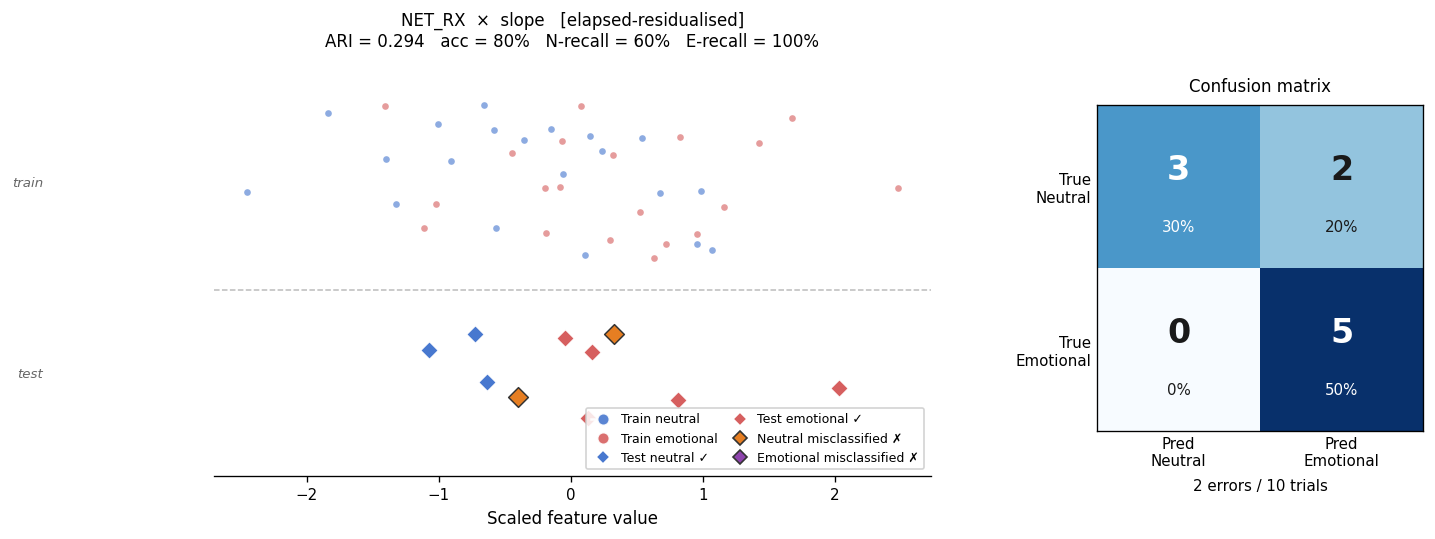

[1/3]  NET_RX × slope  (elapsed-residualised)  →  ARI=0.294  acc=80%  errors=2/10


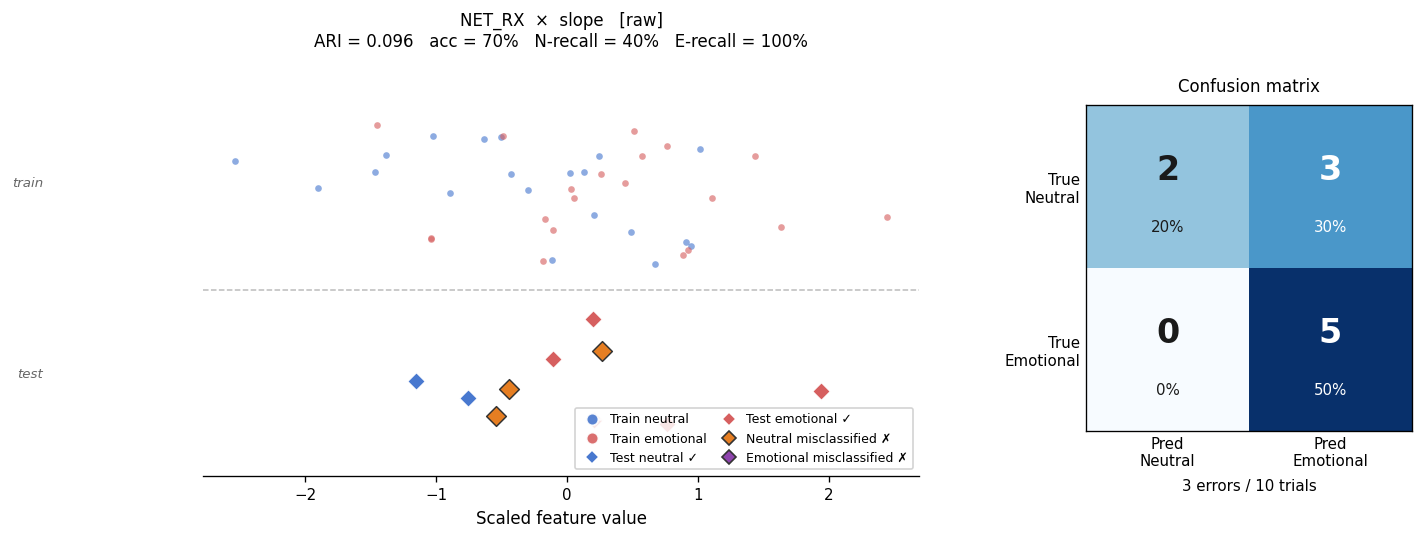

[2/3]  NET_RX × slope  (raw)  →  ARI=0.096  acc=70%  errors=3/10


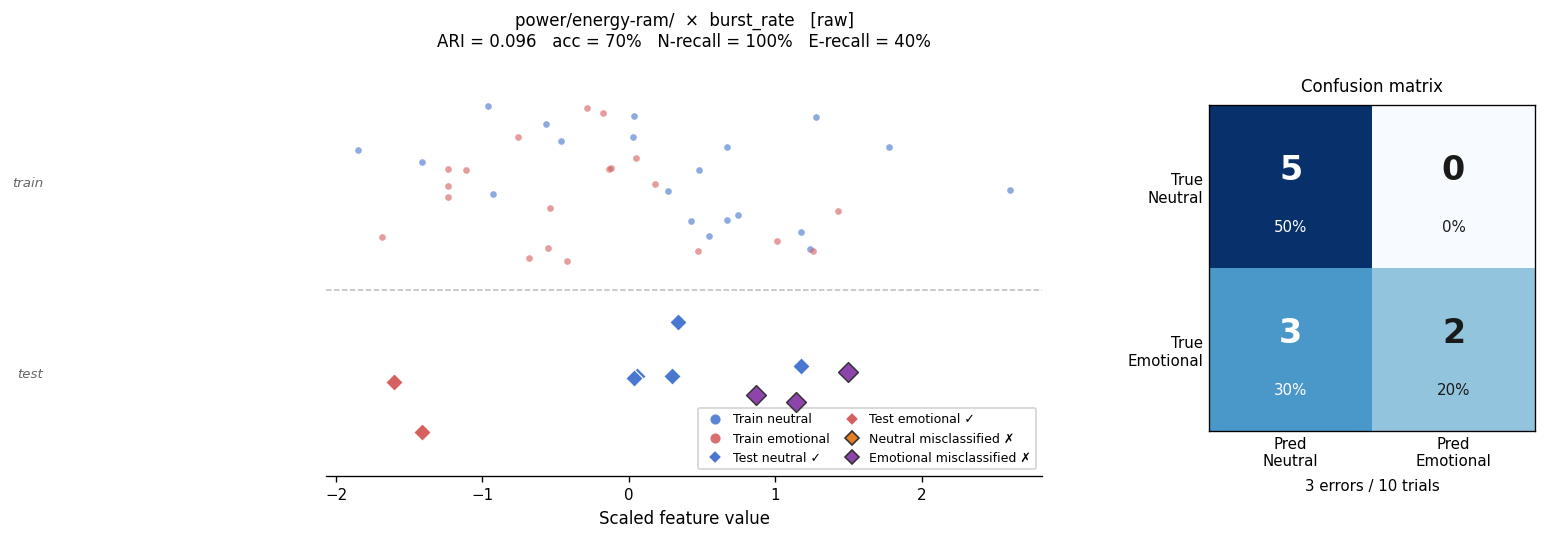

[3/3]  power/energy-ram/ × burst_rate  (raw)  →  ARI=0.096  acc=70%  errors=3/10


In [37]:
# ══════════════════════════════════════════════════════════════════════
# VISUALIZATION — top-6 results: one self-contained figure per pair
# Each figure: left = 1-D strip plot, right = confusion matrix
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

C_NEUTRAL   = '#4878CF'
C_EMOTIONAL = '#D65F5F'
C_MISS_N = '#E67E22'   # orange — misclassified neutral (predicted emotional)
C_MISS_E = '#8E44AD' 

rng = np.random.default_rng(42)

for col_i, r in enumerate(top3_res):

    indicator, metric = r['feat'].split('__', 1)
    indicator_short   = indicator.replace('irq:', '').replace('hat_', '')
    view_tag          = 'elapsed-residualised' if r['view'] == 'resid' else 'raw'

    # ── Scaled feature values ────────────────────────────────────────
    _tr_df = X_raw_resid if r['view'] == 'resid' else X_raw
    _te_df = test_raw_resid if r['view'] == 'resid' else test_raw

    sc_ = StandardScaler().fit(_tr_df[[r['feat']]].fillna(0))
    tr_ = sc_.transform(_tr_df[[r['feat']]].fillna(0)).ravel()
    te_ = sc_.transform(_te_df[[r['feat']]].fillna(0)).ravel()

    tr_n = tr_[y == 0];        tr_e = tr_[y == 1]
    te_n = te_[y_test == 0];   te_e = te_[y_test == 1]

    te_miss_mask = (r['lbl_te'] != y_test)

    # ── Figure ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        1, 2,
        figsize=(13, 4.5),
        gridspec_kw={'width_ratios': [2.2, 1], 'wspace': 0.32}
    )

    # ════════════════════════════════════════════════════════════════
    # LEFT: 1-D strip plot — single axis, colour encodes condition
    # Neutral and emotional points share the same vertical space;
    # train and test are separated into two Y rows.
    # ════════════════════════════════════════════════════════════════
    ax = axes[0]

    HALF_TRAIN = 0.30   # jitter half-width for training row
    HALF_TEST  = 0.22   # jitter half-width for test row
    GAP        = 0.18   # gap between train and test rows
    Y_TRAIN    = 0.0    # centre of training row
    Y_TEST     = -(HALF_TRAIN + GAP + HALF_TEST)  # centre of test row

    # ── Training row ─────────────────────────────────────────────────
    jtr_n = rng.uniform(Y_TRAIN - HALF_TRAIN, Y_TRAIN + HALF_TRAIN, size=len(tr_n))
    jtr_e = rng.uniform(Y_TRAIN - HALF_TRAIN, Y_TRAIN + HALF_TRAIN, size=len(tr_e))

    ax.scatter(tr_n, jtr_n, color=C_NEUTRAL,   alpha=0.62, s=16, linewidths=0)
    ax.scatter(tr_e, jtr_e, color=C_EMOTIONAL, alpha=0.62, s=16, linewidths=0)

    # ── Test row ──────────────────────────────────────────────────────
    jte_n = rng.uniform(Y_TEST - HALF_TEST, Y_TEST + HALF_TEST, size=len(te_n))
    jte_e = rng.uniform(Y_TEST - HALF_TEST, Y_TEST + HALF_TEST, size=len(te_e))

    correct_n = ~te_miss_mask[y_test == 0]
    correct_e = ~te_miss_mask[y_test == 1]
    wrong_n   =  te_miss_mask[y_test == 0]
    wrong_e   =  te_miss_mask[y_test == 1]

    if correct_n.any():
        ax.scatter(te_n[correct_n], jte_n[correct_n],
                   color=C_NEUTRAL,   s=55, marker='D',
                   edgecolors='white', linewidths=0.7, zorder=5)
    if correct_e.any():
        ax.scatter(te_e[correct_e], jte_e[correct_e],
                   color=C_EMOTIONAL, s=55, marker='D',
                   edgecolors='white', linewidths=0.7, zorder=5)
    if wrong_n.any():
        ax.scatter(te_n[wrong_n], jte_n[wrong_n],
                   color=C_MISS_N, s=70, marker='D',
                   edgecolors='#333333', linewidths=0.9, zorder=6)
    if wrong_e.any():
        ax.scatter(te_e[wrong_e], jte_e[wrong_e],
                   color=C_MISS_E, s=70, marker='D',
                   edgecolors='#333333', linewidths=0.9, zorder=6)

    # Divider between train and test rows
    y_div = (Y_TRAIN - HALF_TRAIN + Y_TEST + HALF_TEST) / 2
    ax.axhline(y_div, color='#bbbbbb', lw=0.9, ls='--', zorder=1)

    # Row labels on the left
    ax.text(ax.get_xlim()[0] if hasattr(ax,'_cachedRenderer') else -4,
            Y_TRAIN, 'train', va='center', ha='right',
            color='#666666', fontsize=8, style='italic')
    ax.text(-4, Y_TEST, 'test', va='center', ha='right',
            color='#666666', fontsize=8, style='italic')

    ax.set_xlabel('Scaled feature value', fontsize=10)
    ax.set_yticks([])
    margin = HALF_TRAIN + GAP + HALF_TEST + 0.15
    ax.set_ylim(Y_TEST - HALF_TEST - 0.15, Y_TRAIN + HALF_TRAIN + 0.15)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)

    n_err = int(te_miss_mask.sum())
    n_tot = len(y_test)
    ax.set_title(
        f'{indicator_short}  ×  {metric}   [{view_tag}]\n'
        f'ARI = {r["ari"]:.3f}   acc = {r["acc"]:.0%}   '
        f'N-recall = {r["n_acc"]:.0%}   E-recall = {r["e_acc"]:.0%}',
        fontsize=10, pad=8
    )

    leg_handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_NEUTRAL,
               markersize=7, alpha=0.9, label='Train neutral'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_EMOTIONAL,
               markersize=7, alpha=0.9, label='Train emotional'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_NEUTRAL,
               markersize=6, markeredgecolor='white', label='Test neutral ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_EMOTIONAL,
               markersize=6, markeredgecolor='white', label='Test emotional ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_N,
               markersize=6, markeredgecolor='#333333', label='Neutral misclassified ✗'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_E,
               markersize=6, markeredgecolor='#333333', label='Emotional misclassified ✗'),
    ]
    ax.legend(handles=leg_handles, fontsize=7.5, loc='lower right',
              ncol=2, framealpha=0.85, edgecolor='#cccccc',
              handletextpad=0.4, columnspacing=0.8)

    # ════════════════════════════════════════════════════════════════
    # RIGHT: Confusion matrix — no coloured borders
    # ════════════════════════════════════════════════════════════════
    ax_cm = axes[1]

    cm_mat  = confusion_matrix(y_test, r['lbl_te'])
    n_total = cm_mat.sum()
    vmax_cm = max(cm_mat.max(), 1)

    ax_cm.imshow(cm_mat, cmap='Blues', vmin=0, vmax=vmax_cm, aspect='equal')

    for ri_ in range(2):
        for ci_ in range(2):
            val  = cm_mat[ri_, ci_]
            pct  = val / n_total * 100
            dark = val > vmax_cm * 0.55
            fg   = 'white' if dark else '#1a1a1a'
            ax_cm.text(ci_, ri_ - 0.10, str(val),
                       ha='center', va='center',
                       fontsize=20, fontweight='bold', color=fg)
            ax_cm.text(ci_, ri_ + 0.25, f'{pct:.0f}%',
                       ha='center', va='center',
                       fontsize=9, color=fg)

    ax_cm.set_xticks([0, 1])
    ax_cm.set_xticklabels(['Pred\nNeutral', 'Pred\nEmotional'], fontsize=9)
    ax_cm.set_yticks([0, 1])
    ax_cm.set_yticklabels(['True\nNeutral', 'True\nEmotional'], fontsize=9)
    ax_cm.tick_params(length=0)
    ax_cm.set_xlabel(
        f'{n_err} error{"s" if n_err != 1 else ""} / {n_total} trials',
        fontsize=9, labelpad=6
    )
    ax_cm.set_title('Confusion matrix', fontsize=10, pad=8)

    
    plt.show()
    print(f'[{col_i+1}/{len(top3_res)}]  {indicator_short} × {metric}  '
          f'({view_tag})  →  ARI={r["ari"]:.3f}  acc={r["acc"]:.0%}  '
          f'errors={n_err}/{n_total}')

hat_BLOCK features in test: ['hat_BLOCK__mean_rate', 'hat_BLOCK__slope', 'hat_BLOCK__iat_cv', 'hat_BLOCK__burst_rate', 'hat_BLOCK__burst_clustering', 'hat_BLOCK__variance', 'hat_BLOCK__p90_p10', 'hat_BLOCK__spectral_entropy', 'hat_BLOCK__lz_complexity', 'hat_BLOCK__perm_entropy']


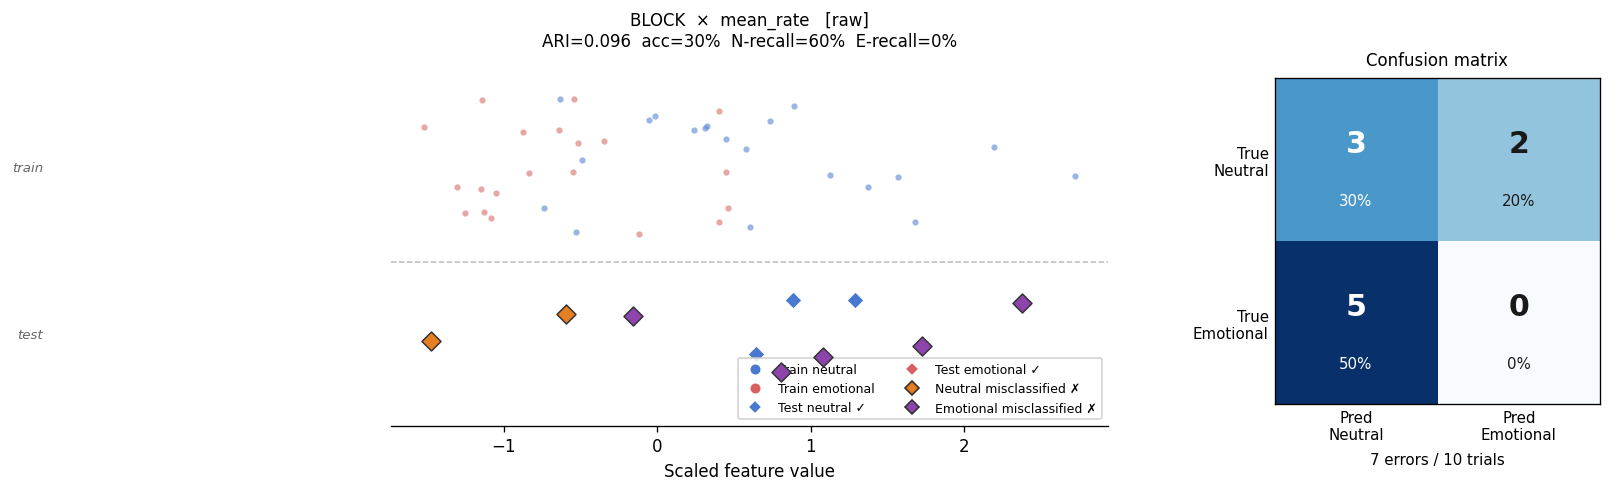

[1/20]  BLOCK × mean_rate (raw)  ARI=0.096  acc=30%  errors=7/10


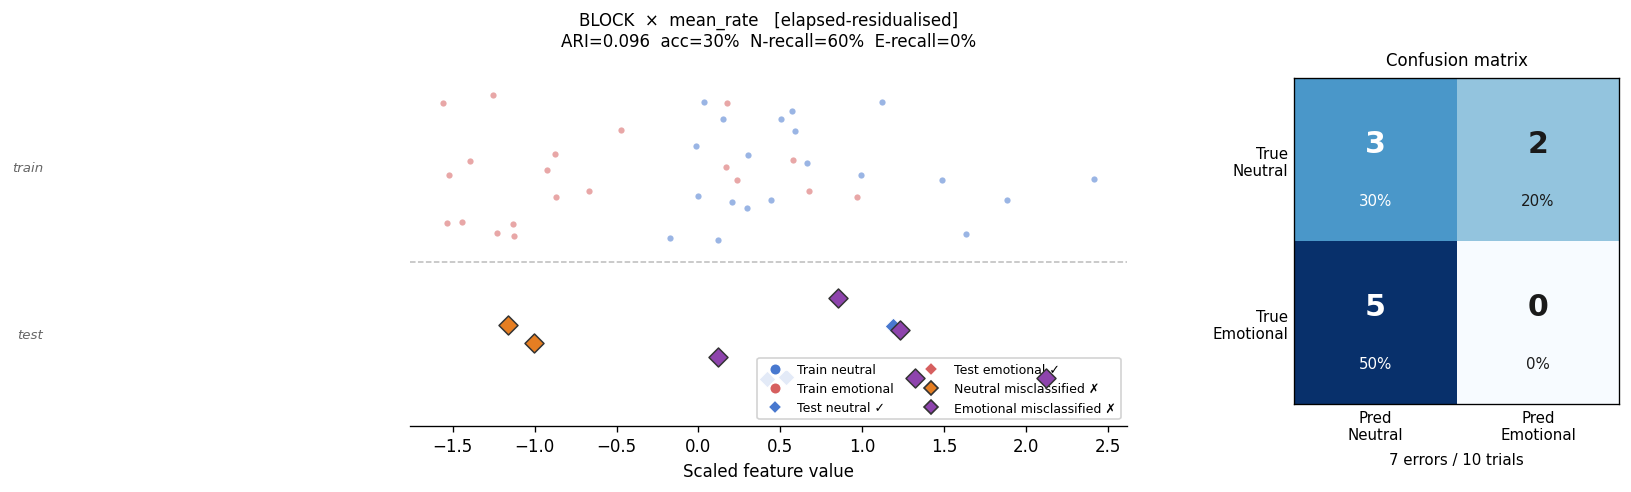

[2/20]  BLOCK × mean_rate (elapsed-residualised)  ARI=0.096  acc=30%  errors=7/10


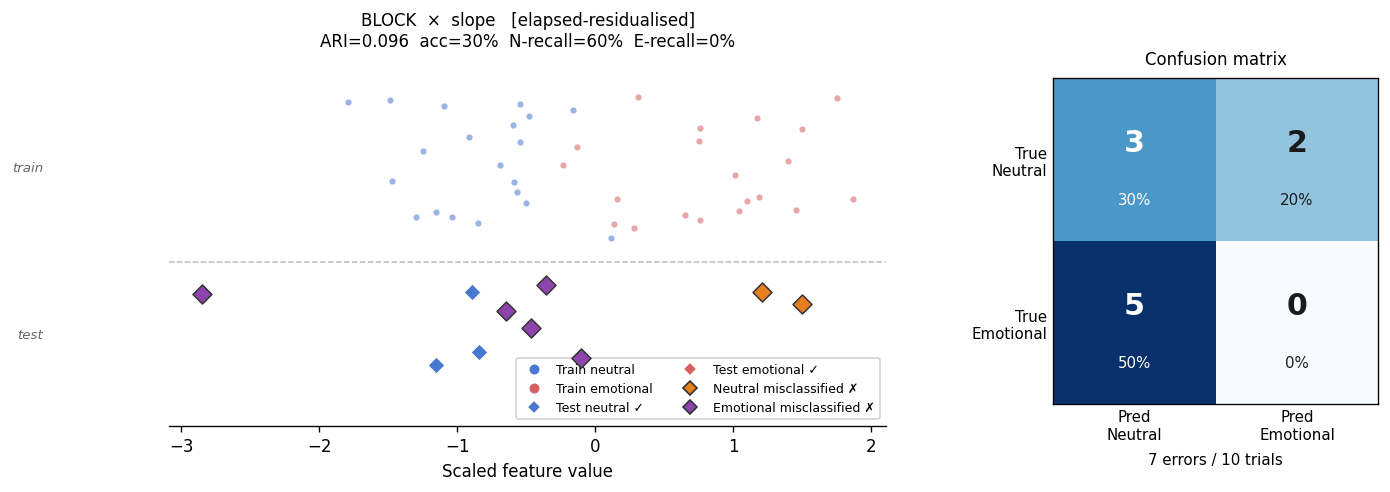

[3/20]  BLOCK × slope (elapsed-residualised)  ARI=0.096  acc=30%  errors=7/10


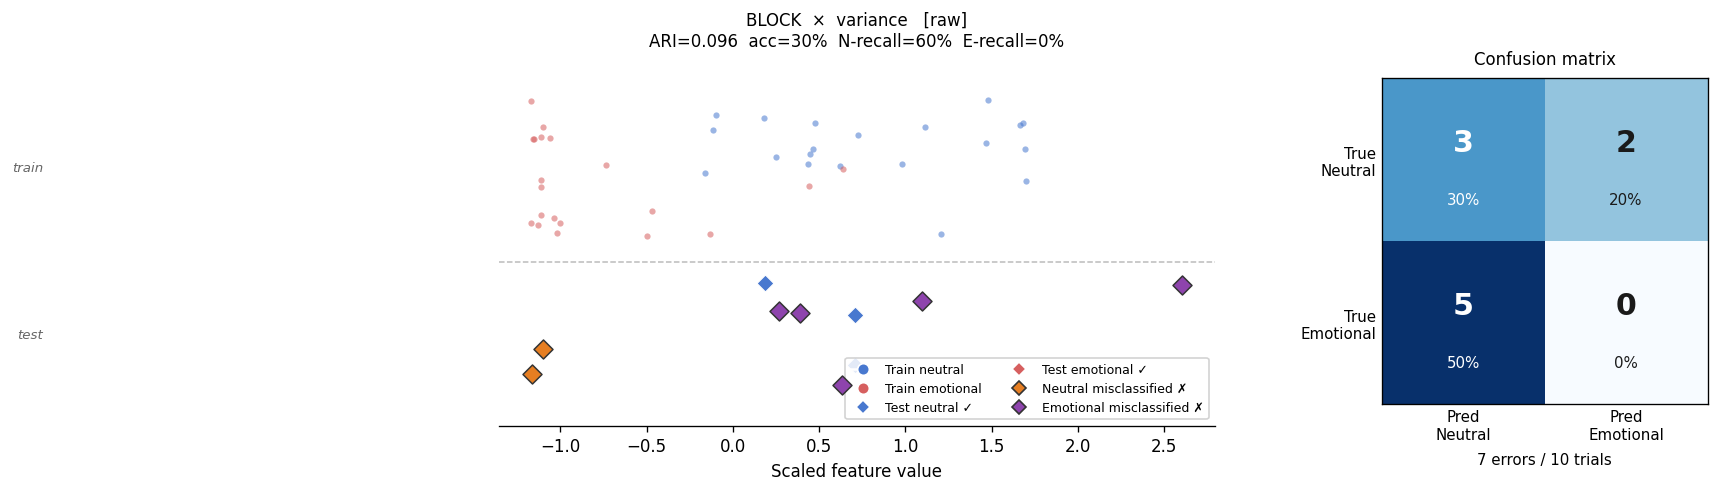

[4/20]  BLOCK × variance (raw)  ARI=0.096  acc=30%  errors=7/10


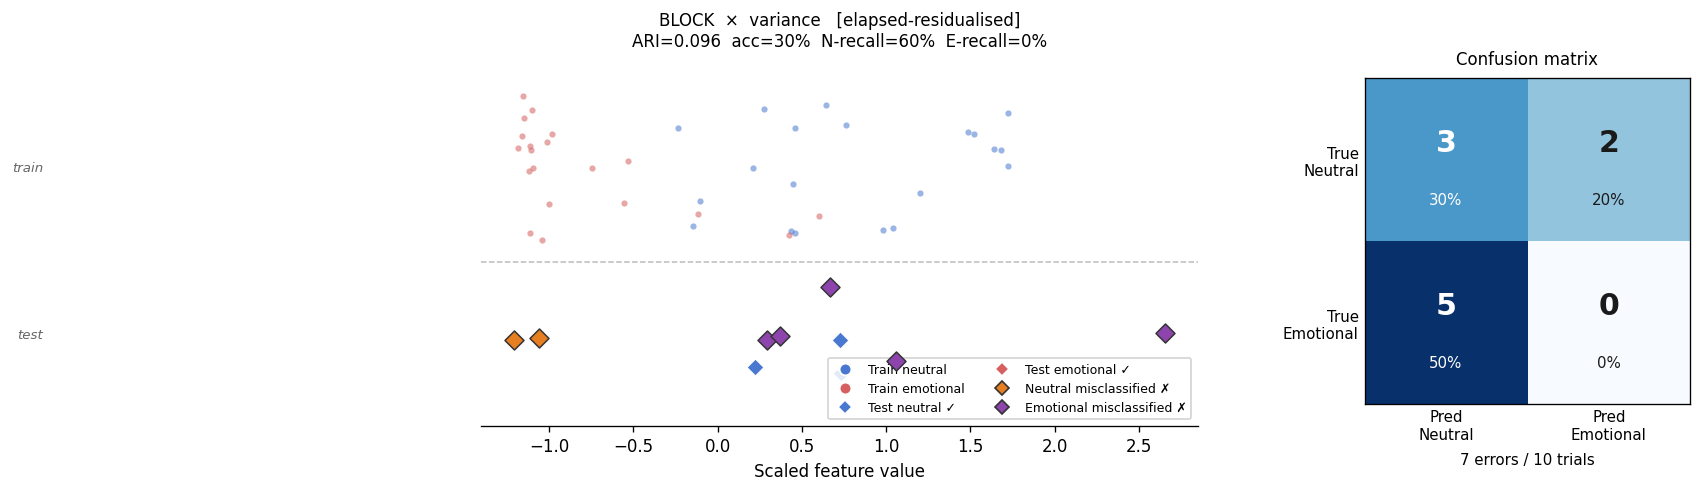

[5/20]  BLOCK × variance (elapsed-residualised)  ARI=0.096  acc=30%  errors=7/10


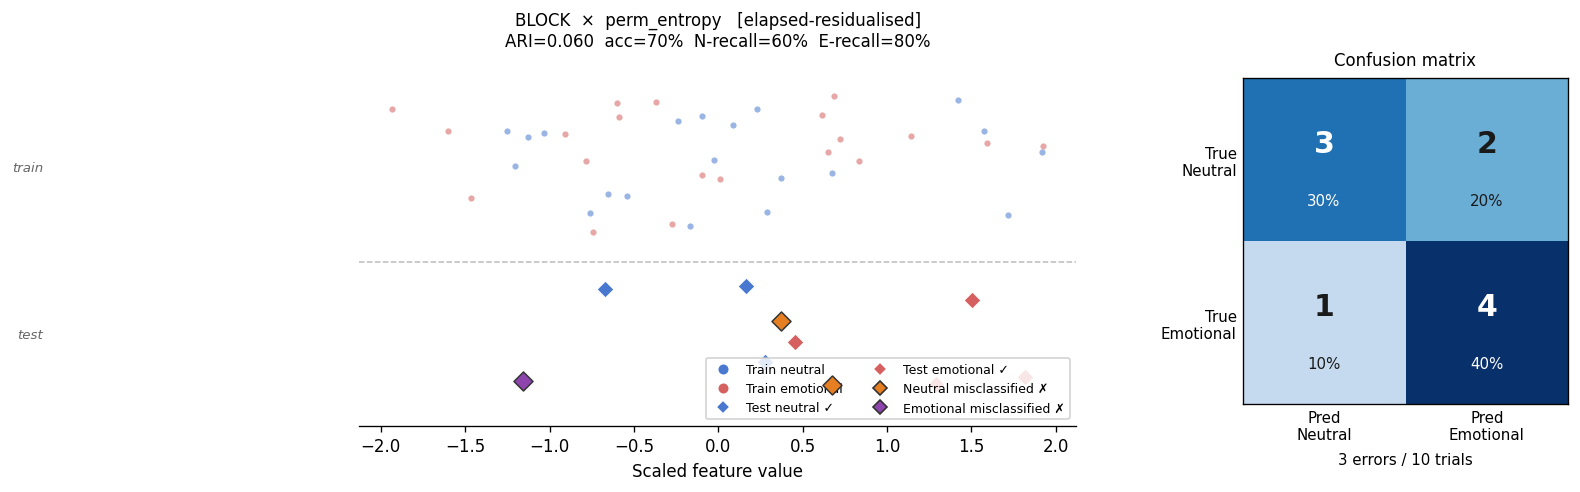

[6/20]  BLOCK × perm_entropy (elapsed-residualised)  ARI=0.060  acc=70%  errors=3/10


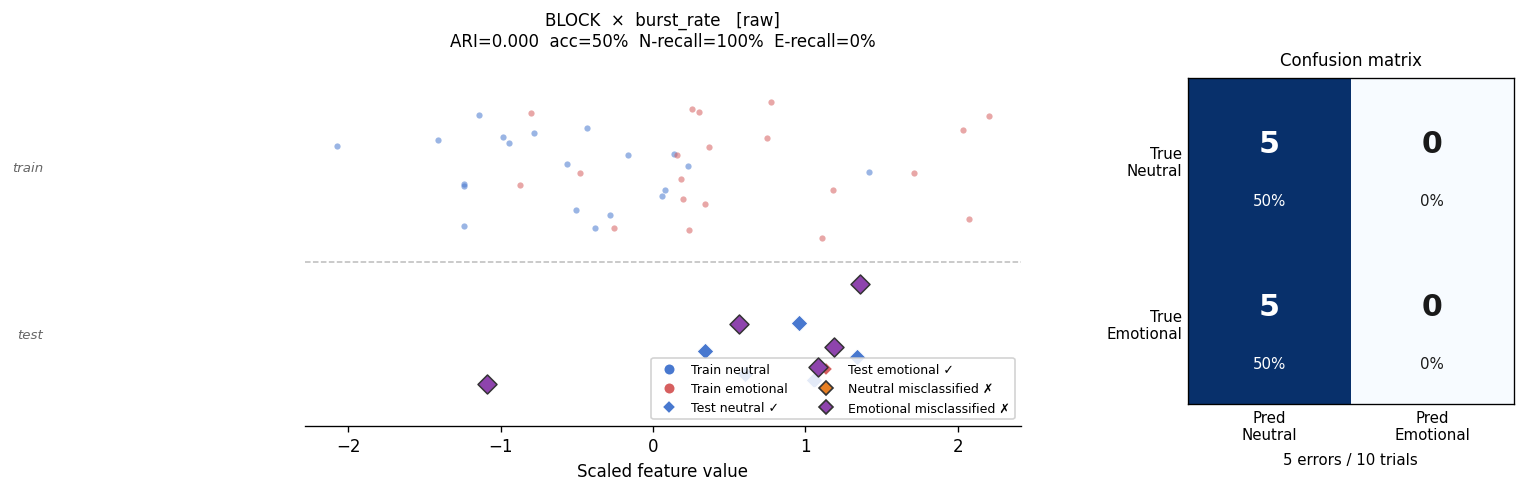

[7/20]  BLOCK × burst_rate (raw)  ARI=0.000  acc=50%  errors=5/10


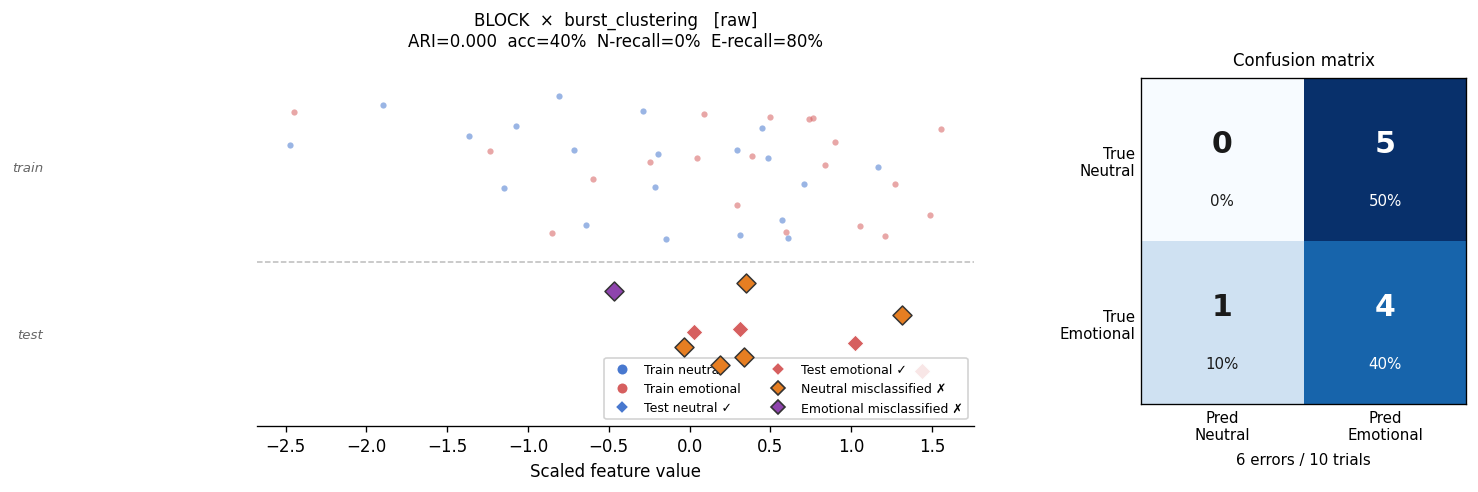

[8/20]  BLOCK × burst_clustering (raw)  ARI=0.000  acc=40%  errors=6/10


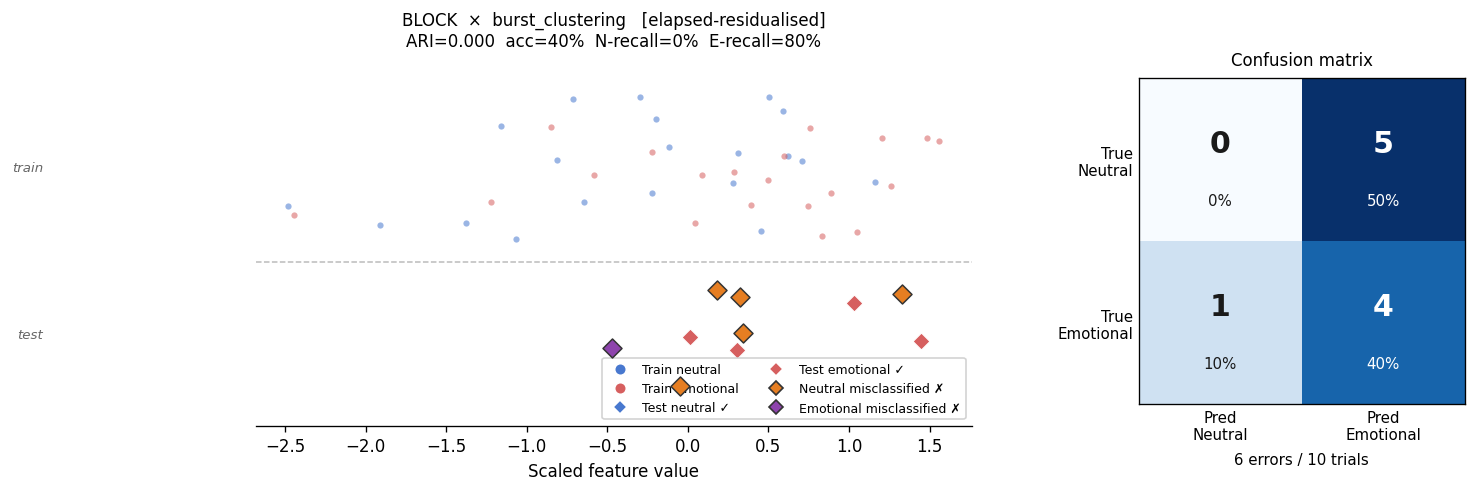

[9/20]  BLOCK × burst_clustering (elapsed-residualised)  ARI=0.000  acc=40%  errors=6/10


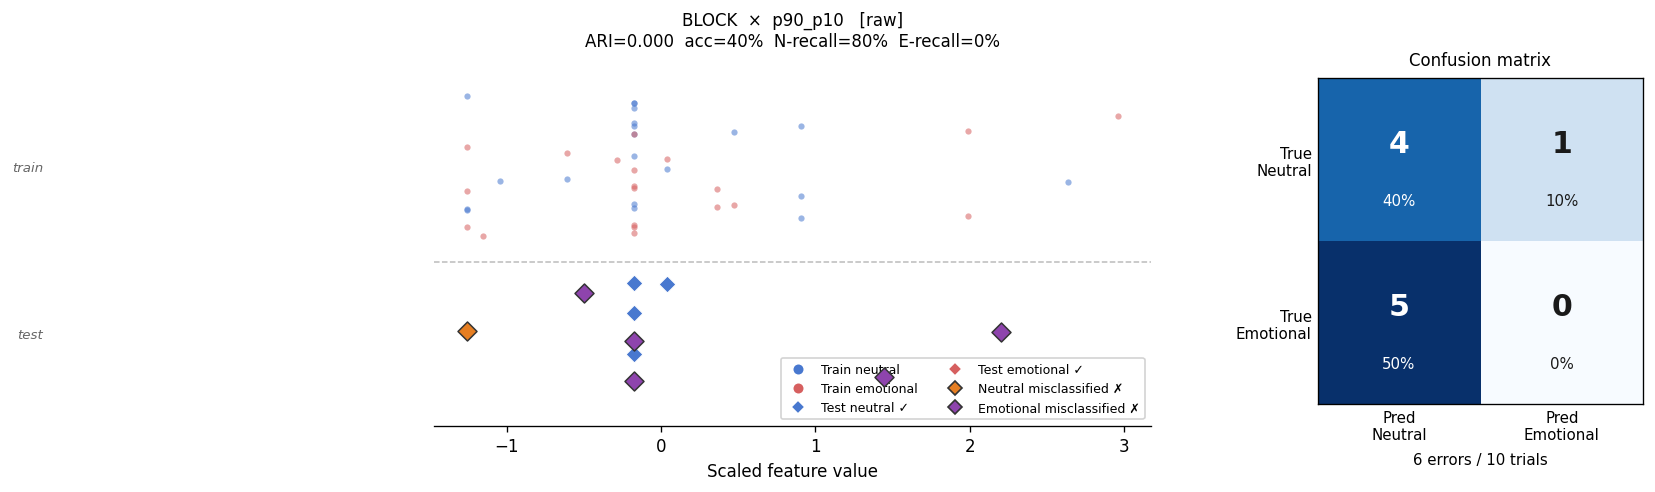

[10/20]  BLOCK × p90_p10 (raw)  ARI=0.000  acc=40%  errors=6/10


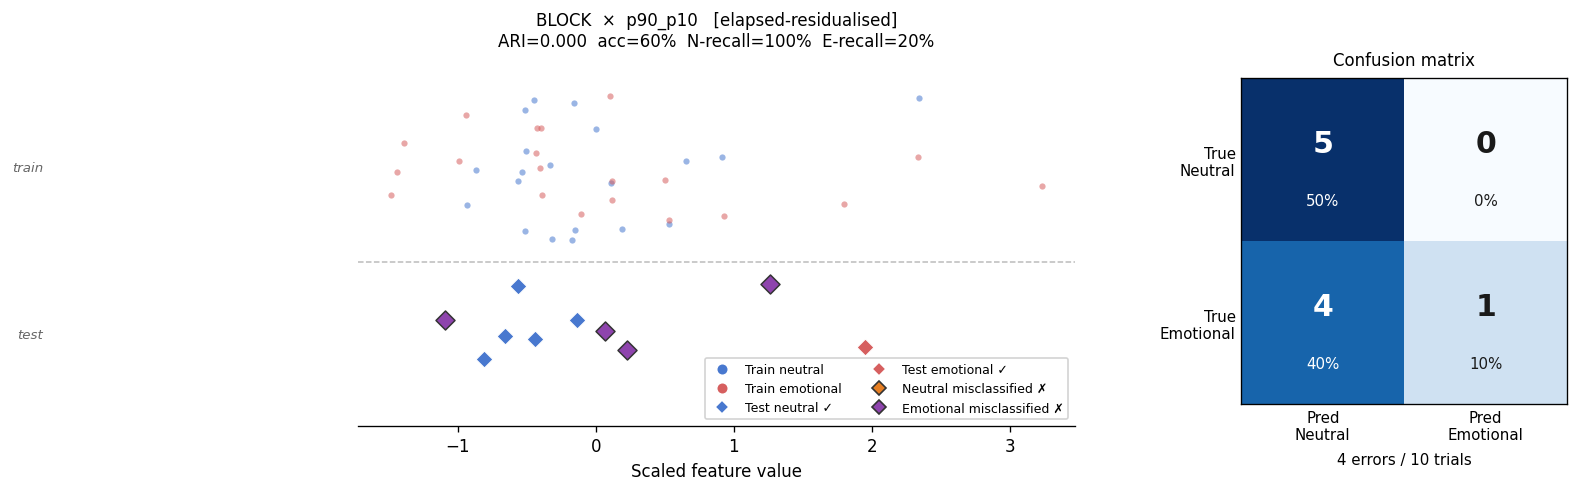

[11/20]  BLOCK × p90_p10 (elapsed-residualised)  ARI=0.000  acc=60%  errors=4/10


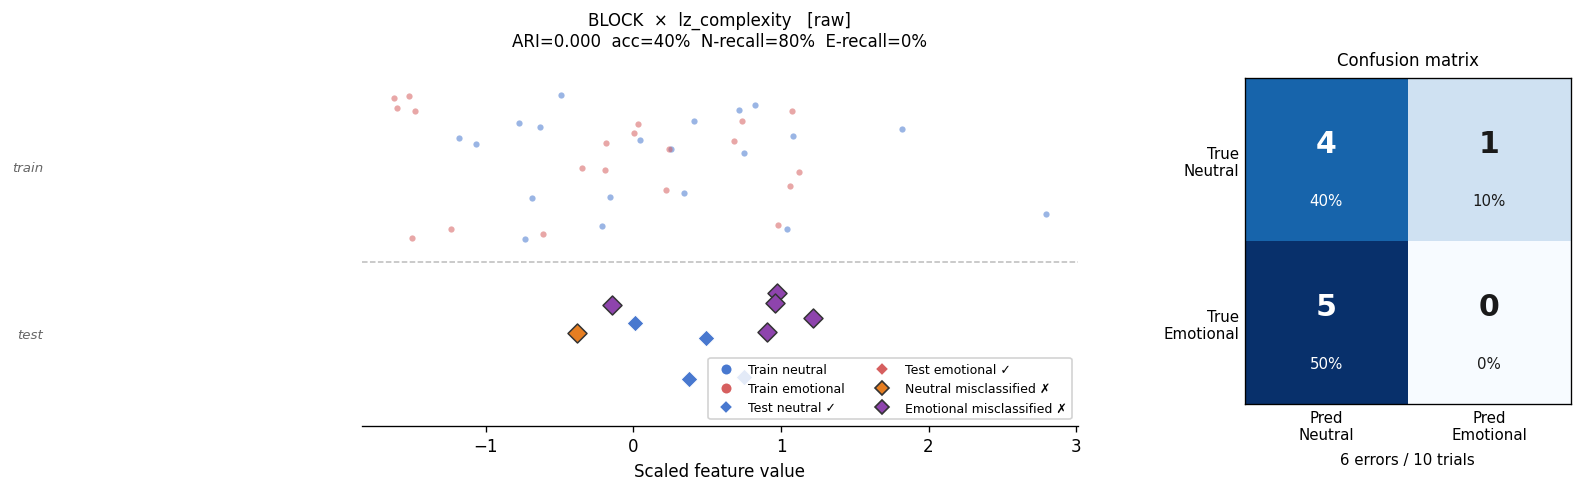

[12/20]  BLOCK × lz_complexity (raw)  ARI=0.000  acc=40%  errors=6/10


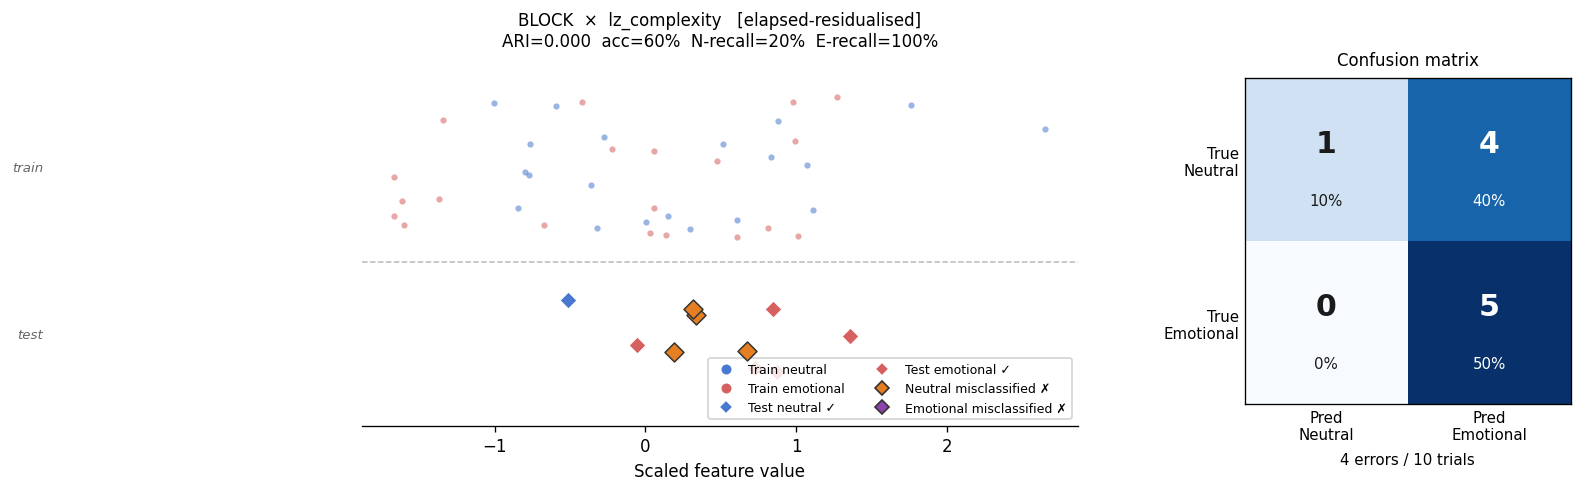

[13/20]  BLOCK × lz_complexity (elapsed-residualised)  ARI=0.000  acc=60%  errors=4/10


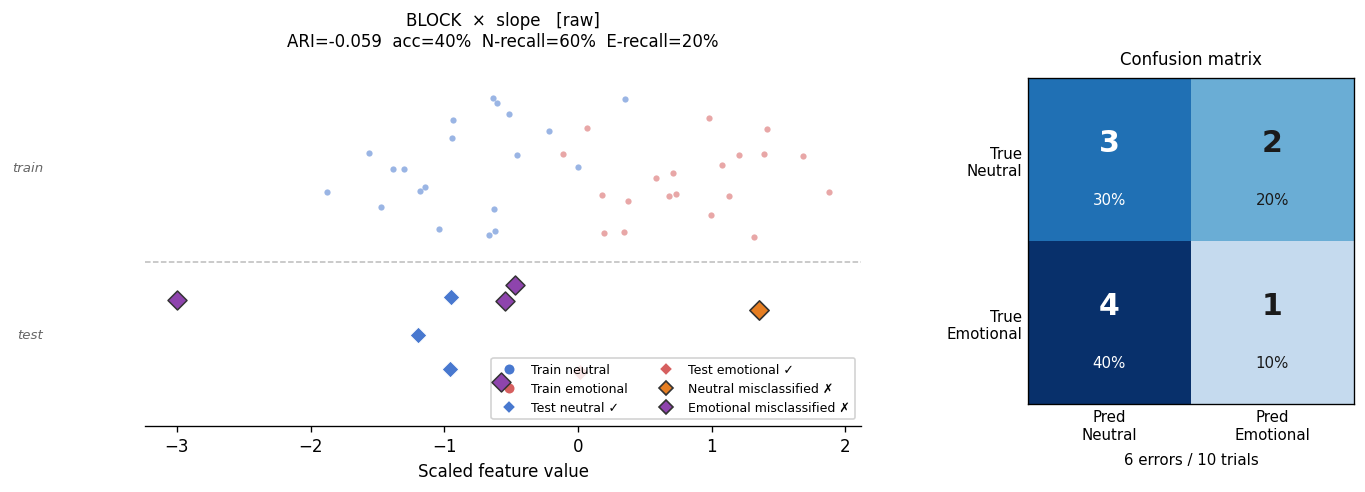

[14/20]  BLOCK × slope (raw)  ARI=-0.059  acc=40%  errors=6/10


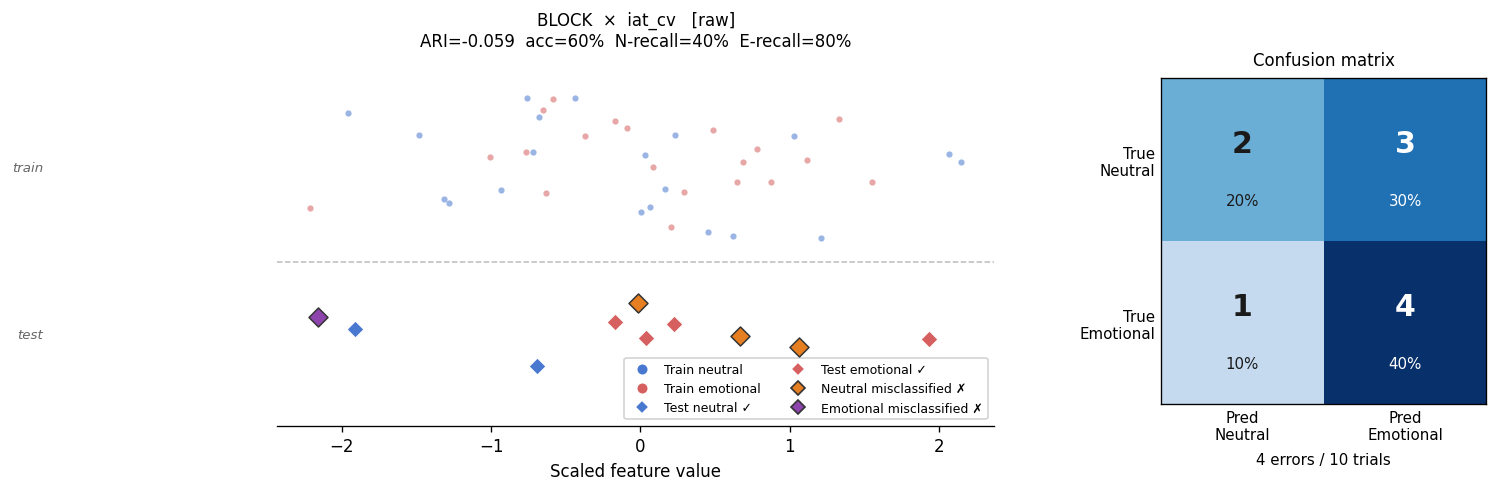

[15/20]  BLOCK × iat_cv (raw)  ARI=-0.059  acc=60%  errors=4/10


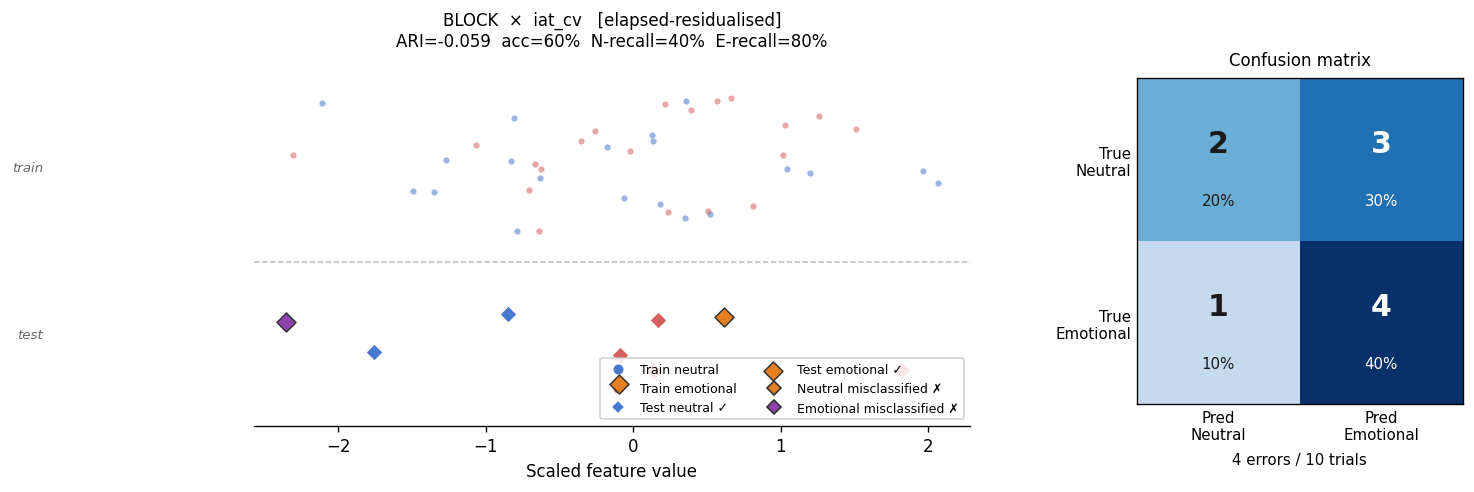

[16/20]  BLOCK × iat_cv (elapsed-residualised)  ARI=-0.059  acc=60%  errors=4/10


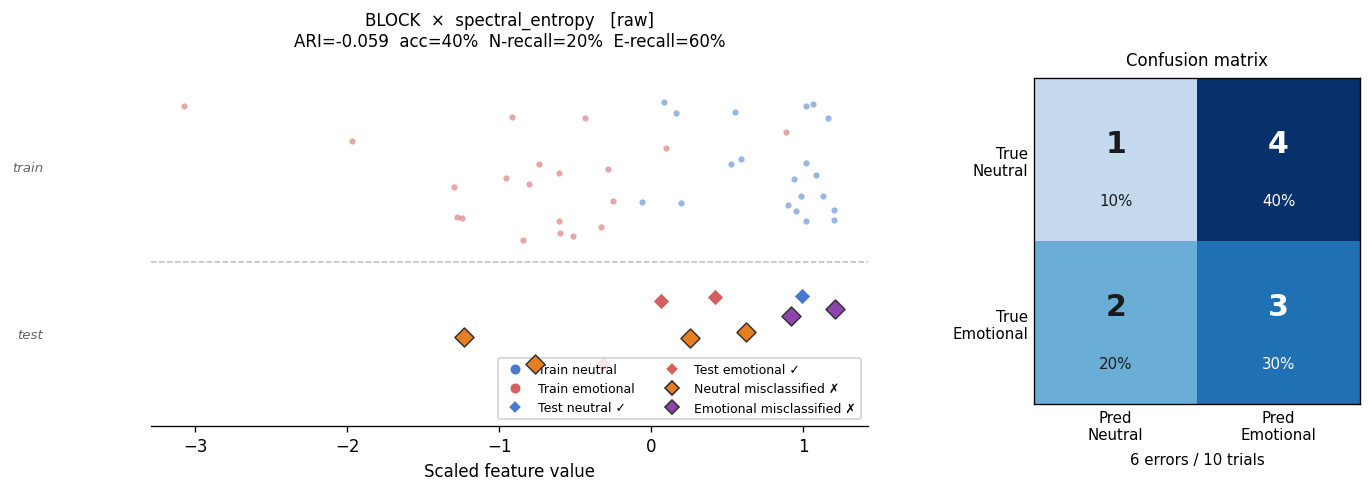

[17/20]  BLOCK × spectral_entropy (raw)  ARI=-0.059  acc=40%  errors=6/10


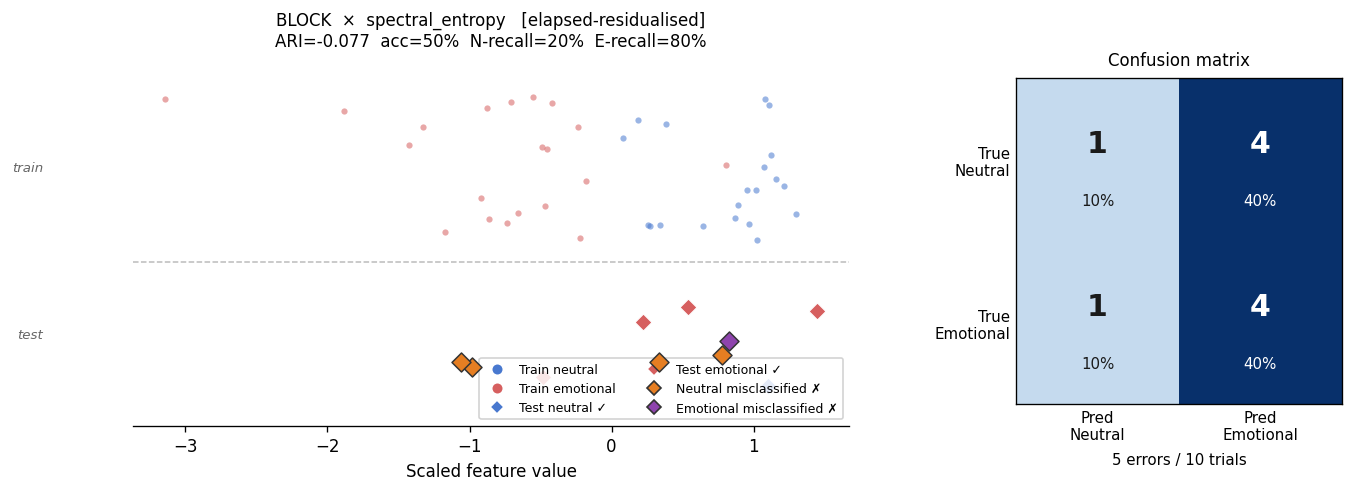

[18/20]  BLOCK × spectral_entropy (elapsed-residualised)  ARI=-0.077  acc=50%  errors=5/10


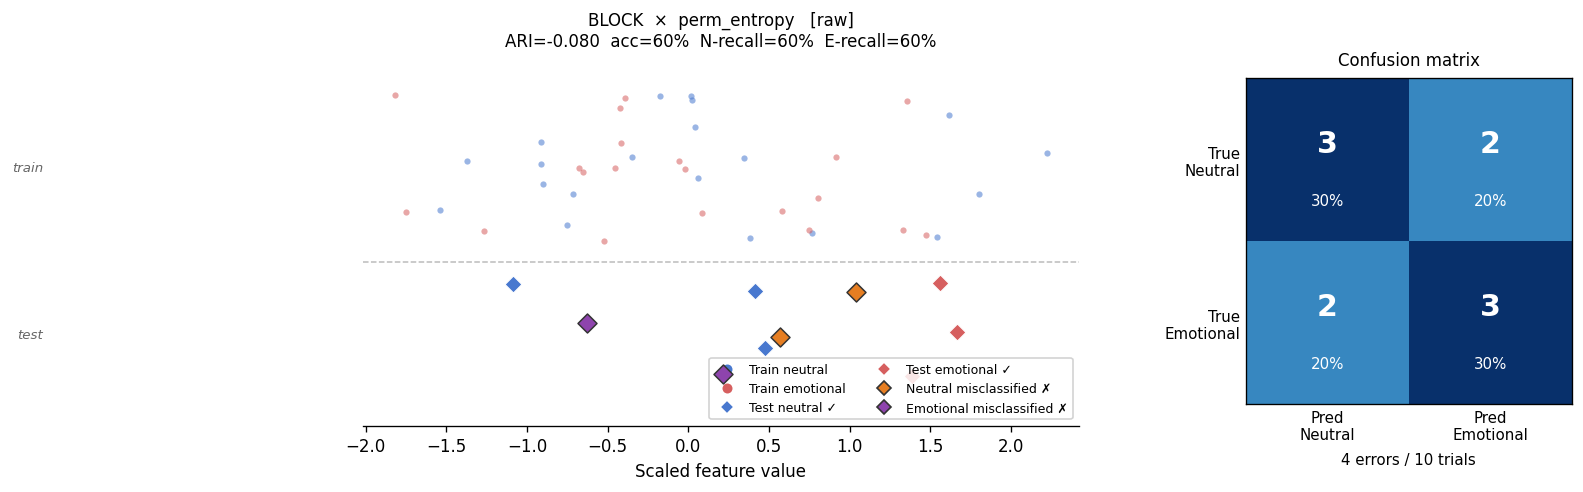

[19/20]  BLOCK × perm_entropy (raw)  ARI=-0.080  acc=60%  errors=4/10


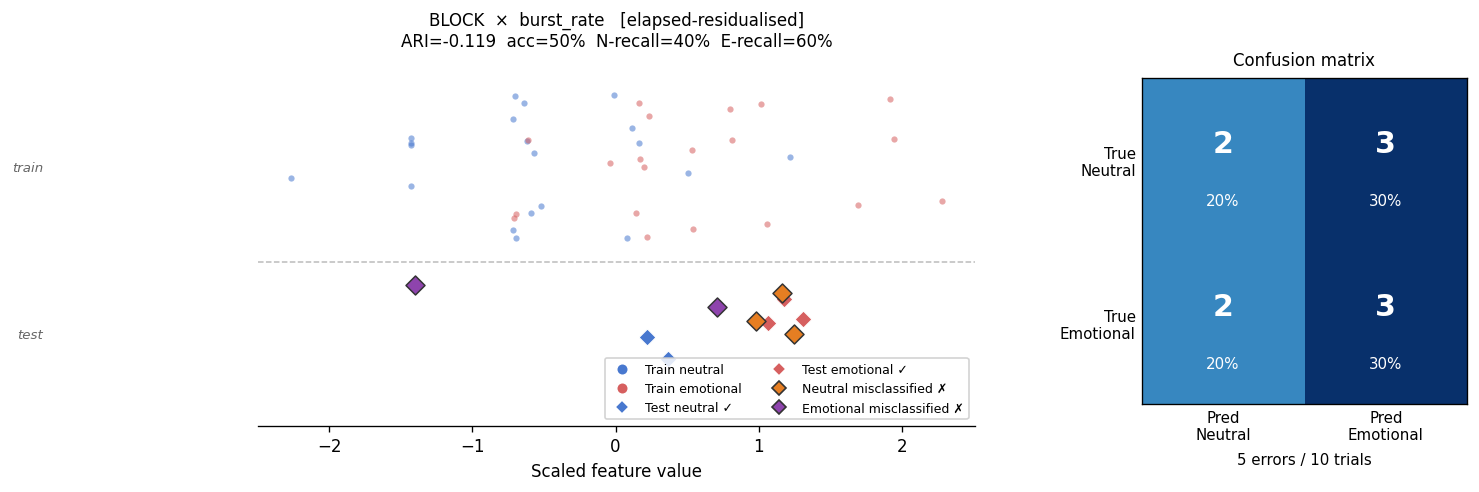

[20/20]  BLOCK × burst_rate (elapsed-residualised)  ARI=-0.119  acc=50%  errors=5/10


In [38]:

# ══════════════════════════════════════════════════════════════════════
# hat_BLOCK features — test set strip plots + confusion matrices
# ══════════════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D

block_feats = [c for c in avail_feat_cols if c.startswith('hat_BLOCK__')]
print(f'hat_BLOCK features in test: {block_feats}')

block_results = []
for _f in block_feats:
    for _view, _tr, _te in [('safe',  X_raw_avail,  test_raw),
                             ('resid', X_raw_resid,  test_raw_resid)]:
        r = _eval_1feat(_f, _tr, _te, y, y_test)
        r['view'] = _view
        block_results.append(r)

# Sort by ARI desc
block_results.sort(key=lambda x: -x['ari'])

for col_i, r in enumerate(block_results):
    indicator, metric = r['feat'].split('__', 1)
    indicator_short   = indicator.replace('hat_', '')
    view_tag          = 'elapsed-residualised' if r['view'] == 'resid' else 'raw'

    _tr_df = X_raw_resid if r['view'] == 'resid' else X_raw_avail
    _te_df = test_raw_resid if r['view'] == 'resid' else test_raw

    sc_ = StandardScaler().fit(_tr_df[[r['feat']]].fillna(0))
    tr_ = sc_.transform(_tr_df[[r['feat']]].fillna(0)).ravel()
    te_ = sc_.transform(_te_df[[r['feat']]].fillna(0)).ravel()

    tr_n = tr_[y == 0];        tr_e = tr_[y == 1]
    te_n = te_[y_test == 0];   te_e = te_[y_test == 1]
    te_miss_mask = (r['lbl_te'] != y_test)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4),
                             gridspec_kw={'width_ratios': [2.2, 1], 'wspace': 0.32})

    ax = axes[0]
    HALF_TRAIN, HALF_TEST, GAP = 0.28, 0.20, 0.16
    Y_TRAIN, Y_TEST = 0.0, -(HALF_TRAIN + GAP + HALF_TEST)

    _rng = np.random.default_rng(42 + col_i)
    ax.scatter(tr_n, _rng.uniform(Y_TRAIN-HALF_TRAIN, Y_TRAIN+HALF_TRAIN, len(tr_n)),
               color=C_NEUTRAL, alpha=0.55, s=14, linewidths=0)
    ax.scatter(tr_e, _rng.uniform(Y_TRAIN-HALF_TRAIN, Y_TRAIN+HALF_TRAIN, len(tr_e)),
               color=C_EMOTIONAL, alpha=0.55, s=14, linewidths=0)

    jte_n = _rng.uniform(Y_TEST-HALF_TEST, Y_TEST+HALF_TEST, len(te_n))
    jte_e = _rng.uniform(Y_TEST-HALF_TEST, Y_TEST+HALF_TEST, len(te_e))
    correct_n = ~te_miss_mask[y_test == 0];  wrong_n = te_miss_mask[y_test == 0]
    correct_e = ~te_miss_mask[y_test == 1];  wrong_e = te_miss_mask[y_test == 1]

    if correct_n.any(): ax.scatter(te_n[correct_n], jte_n[correct_n], color=C_NEUTRAL,   s=52, marker='D', edgecolors='white', linewidths=0.7, zorder=5)
    if correct_e.any(): ax.scatter(te_e[correct_e], jte_e[correct_e], color=C_EMOTIONAL, s=52, marker='D', edgecolors='white', linewidths=0.7, zorder=5)
    if wrong_n.any():   ax.scatter(te_n[wrong_n],   jte_n[wrong_n],   color=C_MISS_N,    s=65, marker='D', edgecolors='#333', linewidths=0.9, zorder=6)
    if wrong_e.any():   ax.scatter(te_e[wrong_e],   jte_e[wrong_e],   color=C_MISS_E,    s=65, marker='D', edgecolors='#333', linewidths=0.9, zorder=6)

    ax.axhline((Y_TRAIN-HALF_TRAIN + Y_TEST+HALF_TEST)/2, color='#bbb', lw=0.9, ls='--')
    ax.text(-4, Y_TRAIN, 'train', va='center', ha='right', color='#666', fontsize=8, style='italic')
    ax.text(-4, Y_TEST,  'test',  va='center', ha='right', color='#666', fontsize=8, style='italic')
    ax.set_yticks([]); ax.set_xlabel('Scaled feature value', fontsize=10)
    ax.set_ylim(Y_TEST-HALF_TEST-0.15, Y_TRAIN+HALF_TRAIN+0.15)
    ax.spines[['top','right','left']].set_visible(False)
    n_err = int(te_miss_mask.sum()); n_tot = len(y_test)
    ax.set_title(f'{indicator_short}  ×  {metric}   [{view_tag}]\n'
                 f'ARI={r["ari"]:.3f}  acc={r["acc"]:.0%}  '
                 f'N-recall={r["n_acc"]:.0%}  E-recall={r["e_acc"]:.0%}', fontsize=10)
    ax.legend(handles=[
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_NEUTRAL,   markersize=7, label='Train neutral'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor=C_EMOTIONAL, markersize=7, label='Train emotional'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_NEUTRAL,   markersize=6, markeredgecolor='white', label='Test neutral ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_EMOTIONAL, markersize=6, markeredgecolor='white', label='Test emotional ✓'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_N,    markersize=6, markeredgecolor='#333', label='Neutral misclassified ✗'),
        Line2D([0],[0], marker='D', color='w', markerfacecolor=C_MISS_E,    markersize=6, markeredgecolor='#333', label='Emotional misclassified ✗'),
    ], fontsize=7.5, loc='lower right', ncol=2, framealpha=0.85)

    ax_cm = axes[1]
    from sklearn.metrics import confusion_matrix as _cm
    cm_mat = _cm(y_test, r['lbl_te'])
    vmax_cm = max(cm_mat.max(), 1)
    ax_cm.imshow(cm_mat, cmap='Blues', vmin=0, vmax=vmax_cm, aspect='equal')
    for ri_ in range(2):
        for ci_ in range(2):
            val = cm_mat[ri_, ci_]; pct = val / n_tot * 100
            fg = 'white' if val > vmax_cm*0.55 else '#1a1a1a'
            ax_cm.text(ci_, ri_-0.10, str(val), ha='center', va='center', fontsize=18, fontweight='bold', color=fg)
            ax_cm.text(ci_, ri_+0.25, f'{pct:.0f}%', ha='center', va='center', fontsize=9, color=fg)
    ax_cm.set_xticks([0,1]); ax_cm.set_xticklabels(['Pred\nNeutral','Pred\nEmotional'], fontsize=9)
    ax_cm.set_yticks([0,1]); ax_cm.set_yticklabels(['True\nNeutral','True\nEmotional'], fontsize=9)
    ax_cm.tick_params(length=0)
    ax_cm.set_xlabel(f'{n_err} error{"s" if n_err!=1 else ""} / {n_tot} trials', fontsize=9, labelpad=6)
    ax_cm.set_title('Confusion matrix', fontsize=10, pad=8)

    plt.tight_layout()
    plt.show()
    print(f'[{col_i+1}/{len(block_results)}]  {indicator_short} × {metric} ({view_tag})  '
          f'ARI={r["ari"]:.3f}  acc={r["acc"]:.0%}  errors={n_err}/{n_tot}')
